In [1]:
# import tensorflow as tf
# # enforce float32 where you expect it
# tf.keras.backend.set_floatx('float32')

# # optionally mixed precision to reduce memory (careful for numeric stability)
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy('mixed_float16')   # optional

# # enable memory growth so TF doesn't pre-allocate the whole GPU
# gpus = tf.config.experimental.list_physical_devices('GPU')
# for g in gpus:
#     tf.config.experimental.set_memory_growth(g, True)

In [2]:
import tensorflow as tf
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import matplotlib.pyplot as plt
from keras.models import load_model
plt.rcParams.update({'font.size': 16})
import time
import numpy as np
from hilbert import decode, encode
import keras
from tf_fourier_features import FourierFeatureProjection

from numpy import loadtxt

from scipy.stats.qmc import Sobol
plt.rcParams.update({'font.size': 18})
import matplotlib as mpl
import matplotlib.ticker as ticker
import os
from PIL import Image
from distutils.version import LooseVersion
import skopt


In [3]:
dtype = 'float32'
rs = lambda x:tf.reshape(tf.convert_to_tensor(x,dtype=dtype),(-1,1))
rs2 = lambda x:tf.reshape(tf.convert_to_tensor(x,dtype=dtype),(-1,2))
sin = lambda x:tf.math.sin(x)
cos = lambda x:tf.math.cos(x)
abs = lambda x:tf.math.abs(x)
mse = lambda x:tf.reduce_mean(tf.square(x))


In [4]:
class SimulationConfig:
    def __init__(self):
        # -------------------------------------------------------
        # Base constants and ranges
        # -------------------------------------------------------
        self.dtype = 'float32'
        self.xmin, self.ymin = 0.0, 0.0
        self.xmax, self.ymax = 1.0, 1.0
        self.tmin, self.tmax = 0.0, 1.0

        # Geometry
        self.X = 5.
        self.Y = 5.
        self.T_ = 900.

        # Model parameters
        self.kappa = 1.0
        self.kappas = 0.25
        self.kappaa = self.kappa - self.kappas
        self.A = 0.07



        # Radiation constants
        self.sigma = 5.67036713e-8
        self.thetas = 800.
        self.n = 1.

        # Two-material case parameters
        self.k = 0.05
        self.rho = 1.85
        self.cv = 849

        # Additional parameters
        self.gmin = 0.0001
        self.gmax = 0.5
        self.theta0 = 1.0
        self.thetabc = 0.5
        self.thetad = 1.0

        self.Bi = lambda h, k: h * self.X / k

        self.alpha = self.X * self.kappaa
        self.nn = 4 * self.n**2

        self.d = self.X / self.Y
        self.S = self.X**(-1) / (3 * self.kappa - self.A * self.kappas)

        # Material 1 and 2
        self.chi = self.k / (self.rho * self.cv)
        self.Fo = self.T_ * self.chi / self.X**2
        self.Bir = self.sigma * self.thetas**3 * self.X / self.k


        self.N_0 = 8000#8000
        self.N_b = 150#6000
        self.N_r = 60000#60000#40000    
        self.N_tmp = 1#4
        self.ex = 0.01


    # -----------------------------------------------------------
    def summary(self):
        """Print important values."""
        print("chi:", self.chi)
        print("Fo:", self.Fo)
        print("Bir:", self.Bir)
        print("alpha:", self.alpha)
        print("nn:", self.nn)
        print("d:", self.d)
        print("S:", self.S)

In [5]:
cfg = SimulationConfig()
cfg.summary()

chi: 3.183395409543819e-05
Fo: 0.0011460223474357748
Bir: 2903.22797056
alpha: 3.75
nn: 4.0
d: 1.0
S: 0.06705783738474434


In [6]:
cfg.Fo * cfg.Bir * cfg.alpha * cfg.nn

49.90746200943558

In [7]:

class PDEFunctions:
    def __init__(self, config):
        # store config locally
        self.cfg = config

    # -----------------------------------------------------------
    # Boundary/initial condition functions
    # -----------------------------------------------------------
    def fun_theta_0(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=self.cfg.dtype) * 0.9

    def fun_theta_b(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=self.cfg.dtype) * 0.5

    def fun_theta_tmp(self, X):
        x,y = X[:,0:1],X[:,1:2]
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=self.cfg.dtype) * 0.4+0.2*y#0.9 - 0.5 * t / self.cfg.tmax

    # -----------------------------------------------------------
    # PDE residuals
    # -----------------------------------------------------------
    def r_1(self, x, y, t, theta, thetax, thetay, thetat,
             thetaxx, thetayy, phi):
        return (
            thetat
            - self.cfg.Fo * (thetaxx + self.cfg.d**2 * thetayy)
            + self.cfg.Fo * self.cfg.Bir * self.cfg.alpha * self.cfg.nn * (theta**4 - phi)
        ) /(self.cfg.alpha * self.cfg.nn)#/self.cfg.T_



    def r_2(self, x, y, t, phi, phixx, phiyy, theta):
        return (-self.cfg.S * (phixx + self.cfg.d**2 * phiyy) + self.cfg.alpha * (phi - theta**4)) 

    # -----------------------------------------------------------
    # Boundary flux functions
    # -----------------------------------------------------------
    def fun_beta(self, theta, thetax, thetay, nx, ny, h):
        return (thetax * nx + self.cfg.d * thetay * ny) + h * (theta - self.cfg.thetabc)

    def fun_gamma(self, phi, phix, phiy, nx, ny, gamma_val):

        return (self.cfg.S * (phix * nx + self.cfg.d * phiy * ny) + gamma_val * (phi - self.cfg.thetabc**4)) 

In [8]:
class DataGenerator:
    def __init__(self, cfg: SimulationConfig, pdefunc: PDEFunctions):
        self.cfg = cfg
        self.pdefunc = pdefunc
        self.n_data = None
        self.yy = None
        self.xx = None
        self.X_data = []
        self.u_data = []
        self.w_data = []  
        self.locsx = None
        self.locsy = None
        self.downx2 = None
        self.downy2 = None

        self.init_locs()

        
        self.generate_data()

    def init_locs(self):

        num_dims = 2
        num_bits = 3
        max_h = 2 ** (num_bits * num_dims)
        hilberts = np.arange(max_h)
        locs = decode(hilberts, num_dims, num_bits)
        
        # сохранить исходные нормировки
        locsx = (locs[:, 0] / 7.0).astype(self.cfg.dtype)
        locsy = ((locs[:, 1] + 2) / (7.0 + 2)).astype(self.cfg.dtype)        
        downx2 = np.array([0,0,0,1,1,2,3,3,4,4,5,6,6,7,7,7]) / 7.0
        downy2 = ((np.array([0,-1,-2,-2,-1,-1,-1,-2,-2,-1,-1,-1,-2,-2,-1,0]) + 2) / (7.0 + 2)).astype(self.cfg.dtype)
        self.locsx = locsx
        self.locsy = locsy
        self.downx2 = downx2
        self.downy2 = downy2
    
    def interval_mask(self,X, yy, i, ex, lst):
        """Строит вертикальную маску для интервала yy[i]..yy[i+1] с учётом соседей."""
        lower = yy[i]
        upper = yy[i+1]
    
        left_in  = (i-1) in lst
        right_in = (i+1) in lst
    
        if not left_in:
            lower += ex
        if not right_in:
            upper -= ex
    
        return (X[:,1] > lower) & (X[:,1] < upper)
    
    
    def apply_block(self,X, base_cond, lst, yy, ex):
        """Добавляет интервалы lst к базовому условию и применяет boolean_mask."""
        cond = base_cond
        for i in lst:
            cond |= self.interval_mask(X, yy, i, ex, lst)
        return tf.boolean_mask(X, cond)


    def quasirandom(self,n_samples, sampler,ex,d):
        space = [(0.0+ex, 1.0-ex)]*d
        if sampler == "LHS":
            sampler = skopt.sampler.Lhs(
                lhs_type="centered", criterion="maximin", iterations=1000
            )
        elif sampler == "Halton":
            sampler = skopt.sampler.Halton(min_skip=-1, max_skip=-1)
        elif sampler == "Hammersley":
            sampler = skopt.sampler.Hammersly(min_skip=-1, max_skip=-1)
        elif sampler == "Sobol":
            # Remove the first point [0, 0, ...] and the second point [0.5, 0.5, ...], which
            # are too special and may cause some error.
            if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
                sampler = skopt.sampler.Sobol(min_skip=2, max_skip=2, randomize=False)
            else:
                sampler = skopt.sampler.Sobol(skip=0, randomize=False)
                return np.array(
                    sampler.generate(space, n_samples + 2)[2:]
                )
        return np.array(sampler.generate(space, n_samples))



        
    def directions(self,x, y, mapping_type="down"):
            dx = np.diff(x)
            dy = np.diff(y)
            out = []
            for ddx, ddy in zip(dx, dy):
                if ddx == 0 and ddy < 0:
                    out.append([-1, 0] if mapping_type == "down" else [1, 0])
                elif ddx == 0 and ddy > 0:
                    out.append([1, 0] if mapping_type == "down" else [-1, 0])
                elif ddx > 0 and ddy == 0:
                    out.append([0, -1] if mapping_type == "down" else [0, 1])
                elif ddx < 0 and ddy == 0:
                    out.append([0, 1] if mapping_type == "down" else [0, -1])
                else:
                    out.append([0, 0])
            return out

    # генерация точек на отрезках — используем те же N_b, tmax, exx, rs, как в вашем коде
    def segment_points(self,x0, x1, y0, y1, N_b, tmax, exx):
        # если у вас есть функция rs (как в исходном), используем её; иначе используем tf.convert_to_tensor
        xs = np.linspace(x0, x1, N_b)[:, None]
        ys = np.linspace(y0, y1, N_b)[:, None]

        xb = rs(xs)      
        yb = rs(ys)

        tb = tf.random.uniform((N_b, 1), exx * self.cfg.tmax, self.cfg.tmax,dtype=self.cfg.dtype)
        return tf.concat([xb, yb, tb], axis=1)
    
    
    def generate_X_b(self,ex):

        # собрать n_b согласно исходной логике (сначала down, затем locs — с разным mapping_type)
        n_b = self.directions(self.downx2, self.downy2, mapping_type="down") + self.directions(self.locsx, self.locsy, mapping_type="locs")
        
        # найти уникальные координаты, как в оригинальном коде
        downxx  = self.downx2[:-1][np.diff(self.downx2) == 0]
        downyy  = self.locsy[1:][np.diff(self.locsx) != 0]
        downxx2 = self.locsx[1:][np.diff(self.locsy) != 0]
        
        self.yy = np.unique(downyy) if len(downyy) else np.array([])
        self.xx = np.unique(downxx2) if len(downxx2) else np.array([])
        

        # собрать X_b — по каждому соседнему парному отрезку
        X_b = []
        for i in range(len(self.downx2) - 1):
            X_b.append(self.segment_points(self.downx2[i], self.downx2[i+1], self.downy2[i], self.downy2[i+1], N_b=self.cfg.N_b, tmax=self.cfg.tmax, exx=self.cfg.ex))
        
        for i in range(len(self.locsx) - 1):
            X_b.append(self.segment_points(self.locsx[i], self.locsx[i+1], self.locsy[i], self.locsy[i+1], N_b=self.cfg.N_b, tmax=self.cfg.tmax, exx=self.cfg.ex))

        n_bx = tf.ones_like(X_b[0][:,0:1])*n_b[0][0]
        n_by = tf.ones_like(X_b[0][:,0:1])*n_b[0][1]
        X_bb = X_b[0]
        for i in range(1,len(X_b)):
            X_bb = tf.concat([X_bb,X_b[i][1:]],axis=0)
            n_bx = tf.concat([n_bx, tf.ones_like(X_b[i][:,0:1][1:])*n_b[i][0]],axis=0)
            n_by = tf.concat([n_by, tf.ones_like(X_b[i][:,0:1][1:])*n_b[i][1]],axis=0)
        n_b_ = tf.concat([n_bx,n_by],axis=1)  
        n_b_,X_bb
        
        return X_bb,n_b_
    def get_cond(self,X_0,ex):
        # ---------------------------------------------------------------------------
        # БЛОК 1
        base = (X_0[:,1] >= self.yy[0]/2 + ex)
        for i in [0,3,6]:
            base |= (X_0[:,0] > self.xx[i] + ex) & (X_0[:,0] < self.xx[i+1] - ex)
        X_0 = tf.boolean_mask(X_0, base)
        
        # ---------------------------------------------------------------------------
        # БЛОК 2
        base = (X_0[:,1] <= 1 - self.yy[0]/2 - ex)
        for i in [0,2,4,6]:
            base |= (X_0[:,0] > self.xx[i] + ex) & (X_0[:,0] < self.xx[i+1] - ex)
        X_0 = tf.boolean_mask(X_0, base)
        
        # ---------------------------------------------------------------------------
        # БЛОК 3
        base = (
            (X_0[:,0] < 1-self.xx[1]-ex) |
            (X_0[:,1] <= self.yy[1]-ex)   |
            (X_0[:,1] >= self.yy[-3] + ex)
        )
        X_0 = self.apply_block(X_0, base, [2,3], self.yy, ex)
        
        # ---------------------------------------------------------------------------
        # БЛОК 4
        base = (
            (X_0[:,0] < 1-self.xx[2]-ex) |
            (X_0[:,0] > 1-self.xx[1]+ex) |
            (X_0[:,1] <= self.yy[0]-ex)   |
            (X_0[:,1] >= self.yy[-3] + ex)
        )
        X_0 = self.apply_block(X_0, base, [3,4,5], self.yy, ex)
        
        # # ---------------------------------------------------------------------------
        # БЛОК 5
        base = (
            (X_0[:,0] < 1-self.xx[3]-ex) |
            (X_0[:,0] > 1-self.xx[2]+ex) |
            (X_0[:,1] <= self.yy[0]-ex)   |
            (X_0[:,1] >= self.yy[-3] + ex)
        )
        X_0 = self.apply_block(X_0, base, [1,3], self.yy, ex)
        
        # ---------------------------------------------------------------------------
        # БЛОК 6
        base = (
            (X_0[:,0] < 1-self.xx[4]-ex) |
            (X_0[:,0] > 1-self.xx[3]+ex) |
            (X_0[:,1] <= self.yy[0]+ex)
        )
        X_0 = self.apply_block(X_0, base, [0,1,2,3], self.yy, ex)
        
        # ---------------------------------------------------------------------------
        # БЛОК 7
        base = (
            (X_0[:,0] < 1-self.xx[5]-ex) |
            (X_0[:,0] > 1-self.xx[4]+ex) |
            (X_0[:,1] <= self.yy[0]-ex)   |
            (X_0[:,1] >= self.yy[-3] + ex)
        )
        X_0 = self.apply_block(X_0, base, [1,3], self.yy, ex)
        
        # ---------------------------------------------------------------------------
        # БЛОК 8
        base = (
            (X_0[:,0] < 1-self.xx[6]-ex) |
            (X_0[:,0] > 1-self.xx[5]+ex) |
            (X_0[:,1] <= self.yy[0]-ex)   |
            (X_0[:,1] >= self.yy[-3] + ex)
        )
        X_0 = self.apply_block(X_0, base, [3,4,5], self.yy, ex)
        
        # ---------------------------------------------------------------------------
        # БЛОК 9
        base = (
            (X_0[:,0] < self.xx[0]-ex) |
            (X_0[:,0] > self.xx[1]+ex) |
            (X_0[:,1] <= self.yy[1]-ex) |
            (X_0[:,1] >= self.yy[-3] + ex)
        )
        X_0 = self.apply_block(X_0, base, [2,3], self.yy, ex)
        
        # ---------------------------------------------------------------------------
        # Финальный отсев
        final_cond = (
            (X_0[:,0] > 0+ex) & (X_0[:,0] < 1-ex) &
            (X_0[:,1] >= 0+ex) & (X_0[:,1] <= 1-ex)
        )
        X_0 = tf.boolean_mask(X_0, final_cond)
        
        # Добавление столбца времени
        return X_0    
    def generate_X_(self,ex,N):
        X_0 = tf.convert_to_tensor(self.quasirandom(N, 'Sobol', 0.0, 2), dtype=self.cfg.dtype)
        X_0 = self.get_cond(X_0,ex)
        return X_0
    def generate_X__(self,ex,N,tmax):
        X__ = self.generate_X_(ex,N)
        X_t = tf.random.uniform((len(X__), 1), ex*tmax, tmax)
        X__ = tf.concat([X__, X_t], axis=1)

        return X__
    def generate_X_r(self):
        X_r = self.generate_X_(self.cfg.ex,self.cfg.N_r)
        X_t = tf.random.uniform((len(X_r), 1), 0+self.cfg.ex*self.cfg.tmax, self.cfg.tmax)
        X_r = tf.concat([X_r, X_t], axis=1)

        return X_r    
    def generate_X_d(self):

        ytmp = []
        xtmp = []
        for i in range(1,len(self.downx2)):
            if (self.downx2[i-1]-self.downx2[i])==0 and (self.downy2[i]-self.downy2[i-1])!=0:
                xtmp.append(self.downx2[i])
                ytmp.append((self.downy2[i]+self.downy2[i-1])/2)
            elif (self.downx2[i]-self.downx2[i-1])!=0 and (self.downy2[i]-self.downy2[i-1])==0:
                xtmp.append((self.downx2[i]+self.downx2[i-1])/2)
                ytmp.append(self.downy2[i])  
        for i in range(1,len(self.locsx)):
            if (self.locsx[i-1]-self.locsx[i])==0 and (self.locsy[i]-self.locsy[i-1])!=0:
                xtmp.append(self.locsx[i])
                ytmp.append((self.locsy[i]+self.locsy[i-1])/2)
            elif (self.locsx[i]-self.locsx[i-1])!=0 and (self.locsy[i]-self.locsy[i-1])==0:
                xtmp.append((self.locsx[i]+self.locsx[i-1])/2)
                ytmp.append(self.locsy[i])  
        Xtmptmp = tf.concat([tf.reshape(tf.convert_to_tensor(xtmp,dtype=self.cfg.dtype),(-1,1)),tf.reshape(tf.convert_to_tensor(ytmp,dtype=self.cfg.dtype),(-1,1))],axis=1)
        X_tmp = tf.random.uniform((0,3),0,0)
        for i in range(10,11):
            Xtmp = tf.concat([Xtmptmp,tf.ones_like(Xtmptmp[:,0:1])*i/10*self.cfg.tmax],axis=1)
            X_tmp = tf.concat([X_tmp,Xtmp],axis=0)    
        fun_d= self.pdefunc.fun_theta_tmp(X_tmp)  
        

        return X_tmp ,fun_d     
    def generate_data(self):
        # Коллокационные точки
#        X_r = self.generate_X_r( self.cfg.ex)
        X_b,n_b = self.generate_X_b( self.cfg.ex)
        X_0 = self.generate_X__(0.0,self.cfg.N_0,0.0)
        X_r = self.generate_X__(self.cfg.ex,self.cfg.N_r,self.cfg.tmax)  
        X_d,theta_d = self.generate_X_d()
        theta_0 = self.pdefunc.fun_theta_0(X_0)
        # Граничные и начальные данные
#        X_d = self.generate_data()
#        theta_d = self.pdefunc.fun_theta_d(X_d[:,0:1],X_d[:,1:2],X_d[:,2:3])

        # Задаем X_data и fun_data
#        self.X_data = [X_r, X_b, X_0, X_d]
        self.X_data = [X_r,X_b,X_0,X_d] 
        self.n_data = n_b
        self.u_data.append(theta_0)
        self.u_data.append(theta_d)
        w_r = tf.Variable(tf.ones_like(X_r[:,0:1]))
        w_b = tf.Variable(tf.ones_like(X_b[:,0:1]))
        w_0 = tf.Variable(tf.ones_like(X_0[:,0:1]))
        w_d = tf.Variable(tf.ones_like(X_d[:,0:1]))
        self.w_data = [w_r,w_b,w_0,w_d]

In [18]:
class Visualization:
    def __init__(self,config,gen, PINN):
        self.cfg = config
        self.gen = gen
        self.PINN = PINN


    def plotu(self, i=0., N=1., save=False, path=None, show=True):
        scale1 = 1.0
        scale2 = 0.0
        NN = 100
        size = 30
        BS = 4096  # batch size for safe GPU inference
    
        # ---- Grid ----
        xspace = np.linspace(0, self.cfg.xmax, NN + 1)
        yspace = np.linspace(0, self.cfg.ymax, NN + 1)
        xx, yy = np.meshgrid(xspace, yspace)
    
        Xgrid = np.column_stack([xx.ravel(), yy.ravel()])
        tcol = np.full((Xgrid.shape[0], 1), i / N)
        XTgrid = np.hstack([Xgrid, tcol]).astype(np.float32)
    
        # ---- Small batched prediction helper ----
        # def batched_predict(model, X):
        #     out = []
        #     X = tf.convert_to_tensor(X, dtype=self.cfg.dtype)
        #     for j in range(0, len(X), BS):
        #         out.append(model(X[j:j+BS]))
        #     return tf.concat(out, axis=0).numpy()
    
        # ---- Model predictions (batched, safe) ----
        tmp1 = self.PINN.models[0](XTgrid)
        tmp2 = self.PINN.models[1](XTgrid)
        tmp3 = self.PINN.models[2](self.gen.X_data[1][:,0:2])  
        tmp4 = self.PINN.models[3](self.gen.X_data[1][:,0:2])    
        U1 = tmp1.numpy().reshape(NN+1,NN+1)
        U2 = tmp2.numpy().reshape(NN+1,NN+1)
        Ub1 = tmp3#.numpy().reshape(NN+1,NN+1)
        Ub2 = tmp4#.numpy().reshape(NN+1,NN+1)

        thetamin,thetamax = tf.reduce_min(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))
        phimin,phimax = tf.reduce_min(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))


        # ---- Fast boolean mask (no Python loops) ----
        mask = self.gen.get_cond(Xgrid, 0.0)
        
        Xgrid = np.asarray(Xgrid)
        mask  = np.asarray(mask)
        
        # View rows as single structured items (fast hashable view in NumPy)
        dtype = np.dtype([('x', Xgrid.dtype), ('y', Xgrid.dtype)])
        
        X_view = Xgrid.view(dtype).ravel()
        M_view = mask.view(dtype).ravel()
        
        # Vectorized membership test
        boolean_array = np.isin(X_view, M_view)
        
        mask = boolean_array.reshape(NN + 1, NN + 1)
        
        U1m = np.where(mask, U1, np.nan)
        U2m = np.where(mask, U2, np.nan)

    
    
        norm_theta = mpl.colors.Normalize(vmin=thetamin * 0.98, vmax=thetamax * 1.02)
        norm_phi   = mpl.colors.Normalize(vmin=phimin * 0.98, vmax=phimax * 1.02)
    
        HH = self.PINN.models[2](self.gen.X_data[1][:, 0:2])*self.cfg.k/self.cfg.X
    
        # ---- Plot ----
        fig, axes = plt.subplots( ncols=2, figsize=(28, 8))
        axes[1].set_xlim(scale2*2-0.01,1-scale2*2+0.01)
        axes[0].set_xlim(scale2*2-0.01,1-scale2*2+0.01) 
        axes[1].set_ylim(scale2*2-0.01,1-scale2*2+0.01)
        axes[0].set_ylim(scale2*2-0.01,1-scale2*2+0.01)         
        axes[0].set_title('$\\theta,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
        img1 = axes[0].pcolormesh(xx,  yy, U1m,norm=norm_theta)  
        img1 = axes[0].contourf(xx,  yy, U1m,levels=np.linspace(float(thetamin)*0.98, float(thetamax)*1.02, 15),norm=norm_theta)  
        cb1 = fig.colorbar(img1, ax=axes[0])  # Just shows colorbar for the last one — optional        
#        contours = axes[0][0].contour(xx, yy, U1, levels=10, colors='black')
#        axes[0][0].clabel(img1, inline=True, fontsize=18, fmt="%.2f"  )  
        img3 =  axes[0].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=np.log10(HH),cmap='magma_r',s=size) 
        cb3 = fig.colorbar(img3,ax=axes[0],location='left')
#        plt.colorbar(img1,ax=axes[0][0]) 

#        img1 = axes.pcolormesh(xx,  yy, U,vmin=vmin,vmax=vmax)  
        axes[1].set_title('$\\varphi,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
        img2 = axes[1].pcolormesh(xx,  yy, U2m,norm=norm_phi)  
        img2 = axes[1].contourf(xx,  yy, U2m,levels=np.linspace(float(phimin)*0.9, float(phimax)*1.1, 15),norm=norm_phi)   
#        contours = axes[0][0].contour(xx, yy, U1, levels=10, colors='black')
#        axes[0][0].clabel(img1, inline=True, fontsize=18, fmt="%.2f"  )  
        img4=  axes[1].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=self.PINN.models[3](self.gen.X_data[1][:,0:2])*(self.cfg.gmax-self.cfg.gmin)+self.cfg.gmin,cmap='magma_r',s=size)     
#        plt.colorbar(img1,ax=axes[0][0]) 
        cb2 = fig.colorbar(img2, ax=axes[1])  # Just shows colorbar for the last one — optional
        cb4 = fig.colorbar(img4, ax=axes[1],location='left')
        cb1.ax.set_title('$\\theta$') 
        cb2.ax.set_title('$\\varphi$')
        cb3.ax.set_title('$log_{10}h$') 
        cb4.ax.set_title('$\\gamma$')         
#        plt.scatter(X_r[:,0:1],X_r[:,1:2],color='white')
#        img1 = axes[0][0].scatter(X_b[:,0:1],X_b[:,1:2],color='black')
    
        cb1.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
        cb1.update_ticks()
        cb2.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
        cb2.update_ticks()
        cb3.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
        cb3.update_ticks()
        cb4.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
        cb4.update_ticks()

        if save:
            os.makedirs(path, exist_ok=True)
            plt.savefig(f"{path}/{int(i)}.png", bbox_inches='tight', dpi=300)
    
        if show:
            plt.show()
    
        plt.close(fig)
    
    # def plotu(self,i=0.,N=1.,save = False,path=None,show=True):#,path=pathur):
    #         scale1 = 1.0#5
    #         scale2 = -0.0#5
    #         NN = 100
    #         size = 30
    #         xspace = np.linspace(0, self.cfg.xmax, NN + 1)
    #         yspace = np.linspace(0, self.cfg.ymax, NN + 1)
    #         xx,yy = np.meshgrid(xspace, yspace)
    #         Xgrid = np.vstack([xx.flatten(),yy.flatten()]).T
    #         XTgrid = np.concatenate([Xgrid,np.ones_like(Xgrid)[:,0:1]*i/N],axis=1)
    #         tmp1 = self.PINN.models[0](XTgrid)
    #         tmp2 = self.PINN.models[1](XTgrid)
    #         tmp3 = self.PINN.models[2](self.gen.X_data[1][:,0:2])  
    #         tmp4 = self.PINN.models[3](self.gen.X_data[1][:,0:2]) 

        
    #         U1 = tmp1.numpy().reshape(NN+1,NN+1)
    #         U2 = tmp2.numpy().reshape(NN+1,NN+1)
    #         Ub1 = tmp3#.numpy().reshape(NN+1,NN+1)
    #         Ub2 = tmp4#.numpy().reshape(NN+1,NN+1)


    #         mask =  self.get_boolean_mask_for_grid(Xgrid,0.0)#self.gen.get_cond(Xgrid, 0.0)
    
    
    #         # mask= np.array(mask)
    #         # Xgrid = np.array(Xgrid)
    #         # mask_set = set(map(tuple, mask))
    #         # boolean_array = np.array([tuple(row) in mask_set for row in Xgrid])
    #         # mask = boolean_array.astype('int').reshape(NN+1,NN+1)
    #         U1m = np.where(mask, U1, np.nan)
    #         U2m = np.where(mask, U2, np.nan)     

    #         thetamin,thetamax = tf.reduce_min(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))
    #         phimin,phimax = tf.reduce_min(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))

    #         norm_theta = mpl.colors.Normalize(vmin=float(thetamin)*0.98, vmax=float(thetamax)*1.02)
    #         norm_phi = mpl.colors.Normalize(vmin=float(phimin)*0.98, vmax=float(phimax)*1.02) 

    
    
        
    #     # vmin = -1
    #         # vmax = 1
    # #        Xtmp = get_cond(XTgrid)
    # #        cmap = plt.get_cmap('gray')    
    #         cmap = plt.get_cmap('viridis')


    #         HH = self.PINN.models[2](self.gen.X_data[1][:,0:2])
    #         plt.set_cmap(cmap)

    #         X_all = Xgrid
       
    #         fig, axes = plt.subplots( ncols=2, figsize=(28, 8))
    #         axes[1].set_xlim(scale2*2-0.01,1-scale2*2+0.01)
    #         axes[0].set_xlim(scale2*2-0.01,1-scale2*2+0.01) 
    #         axes[1].set_ylim(scale2*2-0.01,1-scale2*2+0.01)
    #         axes[0].set_ylim(scale2*2-0.01,1-scale2*2+0.01)         
    #         axes[0].set_title('$\\theta,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
    #         img1 = axes[0].pcolormesh(xx,  yy, U1m,norm=norm_theta)  
    #         img1 = axes[0].contourf(xx,  yy, U1m,levels=np.linspace(float(thetamin)*0.98, float(thetamax)*1.02, 15),norm=norm_theta)  
    #         cb1 = fig.colorbar(img1, ax=axes[0])  # Just shows colorbar for the last one — optional        
    # #        contours = axes[0][0].contour(xx, yy, U1, levels=10, colors='black')
    # #        axes[0][0].clabel(img1, inline=True, fontsize=18, fmt="%.2f"  )  
    #         img3 =  axes[0].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=HH,cmap='magma_r',s=size) 
    #         cb3 = fig.colorbar(img3,ax=axes[0],location='left')
    # #        plt.colorbar(img1,ax=axes[0][0]) 

    # #        img1 = axes.pcolormesh(xx,  yy, U,vmin=vmin,vmax=vmax)  
    #         axes[1].set_title('$\\varphi,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
    #         img2 = axes[1].pcolormesh(xx,  yy, U2m,norm=norm_phi)  
    #         img2 = axes[1].contourf(xx,  yy, U2m,levels=np.linspace(float(phimin)*0.9, float(phimax)*1.1, 15),norm=norm_phi)   
    # #        contours = axes[0][0].contour(xx, yy, U1, levels=10, colors='black')
    # #        axes[0][0].clabel(img1, inline=True, fontsize=18, fmt="%.2f"  )  
    #         img4=  axes[1].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=self.PINN.models[3](self.gen.X_data[1][:,0:2])*(self.cfg.gmax-self.cfg.gmin)+self.cfg.gmin,cmap='magma_r',s=size)     
    # #        plt.colorbar(img1,ax=axes[0][0]) 
    #         cb2 = fig.colorbar(img2, ax=axes[1])  # Just shows colorbar for the last one — optional
    #         cb4 = fig.colorbar(img4, ax=axes[1],location='left')
    #         cb1.ax.set_title('$\\theta$') 
    #         cb2.ax.set_title('$\\varphi$')
    #         cb3.ax.set_title('$log_{10}h$') 
    #         cb4.ax.set_title('$\\gamma$')         
    # #        plt.scatter(X_r[:,0:1],X_r[:,1:2],color='white')
    # #        img1 = axes[0][0].scatter(X_b[:,0:1],X_b[:,1:2],color='black')
        
    #         cb1.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
    #         cb1.update_ticks()
    #         cb2.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
    #         cb2.update_ticks()
    #         cb3.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
    #         cb3.update_ticks()
    #         cb4.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
    #         cb4.update_ticks()
                                 
    
    # #        plt.xlabel('x')
    # #        plt.ylabel('y')
                          
    #         if save==True:
    #             os.makedirs(path, exist_ok=True)   # safe even if folder exists
    #             plt.savefig(f"{path}/{int(i)}.png", bbox_inches='tight', dpi=300)
    #         if show==True:
    #             plt.show()
    #         plt.close(fig) 
        
    def save_all(self,N,path):
        os.makedirs(path, exist_ok=True)   # safe even if folder exists
        for i in range(0,N+1):
            print(i)
            self.plotu(i,N=N,save=True,path = path, show=False)
            
    # def make_gif(self,path):
        
    def plothist(self,hist1,hist2,hist3,save=False,path=None):
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111)
        ax.semilogy(range(len(hist1)),hist1,label='$L_w$')
        ax.semilogy(range(len(hist2)),hist2, label = '$L$')
        ax.semilogy(range(len(hist3)),hist3, label='$J_{obs}$')
        plt.xlabel('epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid()
        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/hist.png", bbox_inches='tight', dpi=300)
        plt.show()
    
    
    def make_gif(self,
        folder_path,
        output_path="",
        frame_duration=60,      # ms per frame
        pause_frames=10,        # extra frames at start & end
        loop=0                  # 0 = infinite loop
    ):
        os.makedirs(output_path, exist_ok=True)   # safe even if folder exists
        # Load and sort image filenames
        files = sorted(
            [f for f in os.listdir(folder_path) if f.endswith(".png")],
            key=lambda x: int(os.path.splitext(x)[0])  # assumes names like 0.png, 1.png ...
        )
    
        if not files:
            raise ValueError("No PNG files found in the folder.")
    
        # Load images
        images = [Image.open(os.path.join(folder_path, f)).convert("RGB") for f in files]
    
        # Add pauses
        start_pause = [images[0]] * pause_frames
        end_pause   = [images[-1]] * pause_frames
    
        frames = start_pause + images + end_pause
    
        # Save GIF
        frames[0].save(
            output_path+"animation.gif",
            save_all=True,
            append_images=frames[1:],
            duration=frame_duration,
            loop=loop,
            optimize=False
        )
    
        print(f"✅ GIF saved as: {output_path}")
    def plot_dataset(self,save=False,path=""):
    
        plt.figure(figsize=(8,6))
        plt.scatter(self.gen.X_data[0][:,0:1],self.gen.X_data[0][:,1:2],s=2,label='Collocation points')
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='red',label='Boundary points')
        plt.scatter(self.gen.X_data[3][:,0:1],self.gen.X_data[3][:,1:2],color='black',marker='X',s=50,label='Observation points')
        plt.legend()

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/dataset.png", bbox_inches='tight', dpi=300)
        plt.show()
        
    def plot_obs(self,save=False,path=""):
        theta = []
        for i in range(1):
            tmp = gen.X_data[3][i*78:(i+1)*78]
            theta.append(PINN.modeltheta(tmp)-gen.u_data[1][i*78:(i+1)*78]) 
        theta2 = []
        for i in range(78):
            tmp = []
            for j in range(1):
                tmp.append(theta[j][i])
            theta2.append(np.mean(tmp))
        
        plt.figure(figsize=(8,6))
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='darkred',label='Boundary',zorder=2)
        plt.scatter(self.gen.X_data[3][0:78,0:1],self.gen.X_data[3][0:78,1:2],c=tf.math.abs(theta2),marker='X',s=75,label='$mean(|\\theta-\\theta|_{obs}|)$',zorder=2)
        plt.colorbar()
        plt.grid(zorder=1)
        plt.legend()

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/obs.png", bbox_inches='tight', dpi=300)
        plt.show()
  
    def plot_domain(self, save=False, path=""):
        plt.figure(figsize=(6,6))
    
        # Create grid
        n = 600
        x = np.linspace(0, 1, n)
        y = np.linspace(0, 1, n)
        X, Y = np.meshgrid(x, y)
    
        XY = np.stack([X.ravel(), Y.ravel()], axis=1).astype(np.float32)
    
        # ---- Get filtered points instead of mask ----
        ex = 0.0
        cond_points = self.gen.get_cond(tf.constant(XY), ex).numpy()
    
        # ---- Build boolean mask from returned points ----
        mask = np.zeros(len(XY), dtype=bool)
    
        # Use a fast hash-based lookup
        grid_points = {tuple(p) for p in XY}
        cond_points_set = {tuple(p) for p in cond_points}
    
        mask = np.array([tuple(p) in cond_points_set for p in XY])
        mask = mask.reshape(n, n)
    
        # ---- Convert mask to NaN-based Z grid ----
        Z = mask.astype(float)
        Z[~mask] = np.nan
    
        # Solid navy colormap
        navy_cmap = ListedColormap(['navy'])
    
        # Plot region
        plt.pcolormesh(
            X, Y, Z,
            cmap=navy_cmap,
            shading="nearest",
            alpha=0.3,
            edgecolors='none'
        )
    
        # Your original points
        plt.scatter(self.gen.X_data[1][:,0], self.gen.X_data[1][:,1],
                    s=3, color='red', label='Boundary', zorder=2)
        plt.scatter(self.gen.X_data[3][:,0], self.gen.X_data[3][:,1],
                    color='black', marker='X', s=50, label='Observation\npoints', zorder=2)
    
        # Legend proxy for filled region
        plt.fill_between([0], [0], [0], color='navy', alpha=0.3, label='Domain')
    
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
    
        plt.grid(zorder=1)
        plt.legend(
            loc='upper left',
            bbox_to_anchor=(0.43, 1.01)
        )
    
        plt.xlabel('x')
        plt.ylabel('y')
    
        if save:
            os.makedirs(path, exist_ok=True)
            plt.savefig(f"{path}/domain.png", bbox_inches='tight', dpi=300)
    
        plt.show()

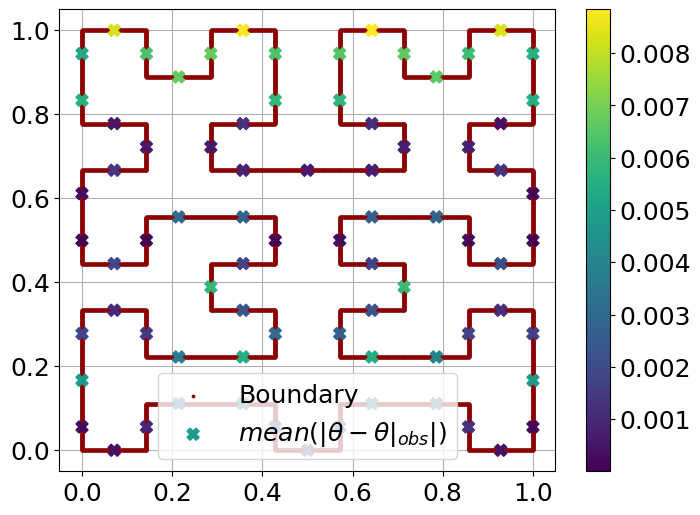

In [22]:
#from matplotlib.colors import ListedColormap
      
vis = Visualization(cfg,gen, PINN)
vis.plot_obs(save=True,path=r"C:\Users\Voland\Desktop\art\oop2\obs/")
#vis.plot_domain(save=True,path=r'C:\Users\Voland\Desktop\art\oop2')

In [10]:
class PINN:
    def __init__(self, config):
        self.cfg = config

        # Pass config to each model
        self.modeltheta = self.MyModelT(self.cfg)
        self.modelphi   = self.MyModelPhi(self.cfg)
        self.modelh     = self.MyModelH(self.cfg)
        self.modelgamma = self.MyModelGamma(self.cfg)

        self.models = [self.modeltheta, self.modelphi,
                       self.modelh, self.modelgamma]

    class BasePINN(tf.keras.Model):
        """
        Base class for PINN models.
        """
        def __init__(self, cfg,
                     num_hidden_layers=3, hidden_dim=30,
                     output_activation='linear',
                     output_init='zeros',
                     use_time=True):

            super().__init__()

            # store config locally
            self.cfg = cfg
            self.use_time = use_time

            # Fourier projections
            self.r_proj = FourierFeatureProjection(
                gaussian_projection=16,
                gaussian_scale=1.0 / cfg.xmax
            )
            self.phi_proj = FourierFeatureProjection(
                gaussian_projection=16,
                gaussian_scale=1.0 / cfg.ymax
            )
            if use_time:
                self.t_proj = FourierFeatureProjection(
                    gaussian_projection=16,
                    gaussian_scale=1.0 / cfg.tmax
                )

            # Hidden layers
            self.hidden_layers = [
                tf.keras.layers.Dense(hidden_dim, activation='tanh')
                for _ in range(num_hidden_layers)
            ]

            # Output layer
            self.output_layer = tf.keras.layers.Dense(
                1,
                activation=output_activation,
                bias_initializer=output_init,
                kernel_initializer='zeros'
            )

            self.c = tf.Variable(1.0, trainable=False, name='c_scale')

        def project_inputs(self, inputs):
            z = self.r_proj(inputs[:, 0:1])
            r = self.phi_proj(inputs[:, 1:2])

            if self.use_time:
                t = self.t_proj(inputs[:, 2:3])
                return tf.concat([z, r, t], 1)
            else:
                return tf.concat([z, r], 1)

        def call(self, inputs):
            x = self.project_inputs(inputs)
            for layer in self.hidden_layers:
                x = layer(x)
            return self.output_layer(x)

    class MyModelT(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='linear',
                output_init='ones',
                use_time=True
            )

        def call(self, inputs):
            return super().call(inputs) * self.c

    class MyModelPhi(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='sigmoid',
                output_init='ones',
                use_time=True
            )
        def call(self, inputs):
            base = super().call(inputs)
            return  base 
    class MyModelH(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='linear',
                output_init='zeros',
                use_time=False
            )

        def call(self, inputs):
            base = super().call(inputs)
            return  10**base + 1e-8

    class MyModelGamma(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='sigmoid',
                output_init='ones',
                use_time=False
            )
    def save(self, path):
        # Make folder if needed

        os.makedirs(path, exist_ok=True)
    
        self.modeltheta.save(f"{path}/modeltheta")
        self.modelphi.save(f"{path}/modelphi")
        self.modelh.save(f"{path}/modelh")
        self.modelgamma.save(f"{path}/modelgamma")
    
        print("Models saved to:", path)    
    def load(self, path):
        self.modeltheta = tf.keras.models.load_model(f"{path}modeltheta")
        self.modelphi   = tf.keras.models.load_model(f"{path}modelphi")
        self.modelh     = tf.keras.models.load_model(f"{path}modelh")
        self.modelgamma = tf.keras.models.load_model(f"{path}modelgamma")
        
        self.models = [self.modeltheta, self.modelphi,
                       self.modelh, self.modelgamma]
    

In [11]:
class Train:
    def __init__(self,
                 cfg,
                 gen,
                 pdefunc,
                 PINN,
                vis):

        # models
        self.cfg = cfg
        self.gen = gen
        self.pdefunc = pdefunc
        self.PINN = PINN
        self.vis = vis
        self.hist1 = []
        self.hist2 = []
        self.hist3 = []        
        self.tf_optimizer1 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)      
        self.tf_optimizer2 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)   
        self.tf_optimizer3 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)      
        self.tf_optimizer4 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)       
        self.tf_optimizer5 = tf.keras.optimizers.Adam(lr = 1e-3, beta_1=.99) 
        # data
        
        # shortcuts
        self.mse = lambda x: tf.reduce_mean( tf.square( x ) )
        self.abs = lambda x: tf.math.abs(x) 



    # ---------------------------------------------------------
    # ------ Shared gradient helper for r1/r2  ----------------
   # ---------------------------------------------------------

    @tf.function
    def _compute_grads_theta_phi(self, x, y, t):

        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])
            inp = tf.concat([x, y, t], axis=1)

            theta = self.PINN.models[0](inp)
            phi   = self.PINN.models[1](inp)

            theta_x = tape.gradient(theta, x)
            theta_y = tape.gradient(theta, y)
            phi_x   = tape.gradient(phi, x)
            phi_y   = tape.gradient(phi, y)

        # second derivatives + theta_t
        theta_t  = tape.gradient(theta, t)
        theta_xx = tape.gradient(theta_x, x)
        theta_yy = tape.gradient(theta_y, y)
        phi_xx   = tape.gradient(phi_x, x)
        phi_yy   = tape.gradient(phi_y, y)

        del tape
        return theta, phi, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi_xx, phi_yy

    # ---------------------------------------------------------
    # ---------------- r1  and  r2 -----------------------------
    # ---------------------------------------------------------

    @tf.function
    def get_r(self, X):
        x, y, t = X[:, 0:1], X[:, 1:2], X[:, 2:3]

        theta, phi, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi_xx, phi_yy = self._compute_grads_theta_phi(x, y, t)
        r1 = self.pdefunc.r_1(x, y, t, theta, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi)
        r2 = self.pdefunc.r_2(x, y, t, phi, phi_xx, phi_yy, theta)
        return r1, r2

    # ---------------------------------------------------------
    # ---------------- Boundary terms b1,b2 -------------------
    # ---------------------------------------------------------

    @tf.function
    def get_b(self, X_b, n_b):
        x, y, t = X_b[:, 0:1], X_b[:, 1:2], X_b[:, 2:3]

        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])

            inp = tf.concat([x, y, t], axis=1)
            theta = self.PINN.models[0](inp)
            phi = self.PINN.models[1](inp)

        theta_x = tape.gradient(theta, x)
        theta_y = tape.gradient(theta, y)
        phi_x = tape.gradient(phi, x)
        phi_y = tape.gradient(phi, y)
        del tape

        gamma = self.PINN.models[3](tf.concat([x, y], 1)) * (self.cfg.gmax - self.cfg.gmin) + self.cfg.gmin
        h     = self.PINN.models[2](tf.concat([x, y], 1))

        r1 = self.pdefunc.fun_beta(theta, theta_x, theta_y, n_b[:, 0:1], n_b[:, 1:2], h)
        r2 = self.pdefunc.fun_gamma(phi, phi_x, phi_y, n_b[:, 0:1], n_b[:, 1:2], gamma)
        return r1, r2

    # ---------------------------------------------------------
    # ----------------------- Loss -----------------------------
    # ---------------------------------------------------------

    @tf.function
    def compute_loss(self):

        # PDE residuals
        r1, r2 = self.get_r(self.gen.X_data[0])

        # boundary
        theta_b, phi_b = self.get_b(self.gen.X_data[1],self.gen.n_data)


        # initial & tmp conditions
        theta_0    = self.PINN.models[0](self.gen.X_data[2]) - self.gen.u_data[0]
        theta_tmp = self.PINN.models[0](self.gen.X_data[3]) - self.gen.u_data[1]


        # weighted losses
        w1, w2, w3, w4 = self.gen.w_data

        loss_r   = self.mse(w1 * self.abs(r1)) + self.mse(w1 * self.abs(r2))
        loss_b   = self.mse(w2 * self.abs(theta_b)) + self.mse(w2 * self.abs(phi_b))
        loss_0   = self.mse(w3 * self.abs(theta_0))
        loss_tmp = self.mse(w4 * self.abs(theta_tmp))

        loss_all = loss_r + loss_b + loss_0 + loss_tmp

        # second return term unchanged
        detail_loss = (
            self.mse(r1) + self.mse(r2) +
            self.mse(theta_b) + self.mse(phi_b) +
            self.mse(theta_0)
        )

        return loss_all, detail_loss, self.mse(theta_tmp)

    # ---------------------------------------------------------
    # ------------------- Gradient Step ------------------------
    # ---------------------------------------------------------

    @tf.function
    def get_grad(self):
        with tf.GradientTape(persistent=True) as tape:
            loss_all, loss_details, loss_tmp = self.compute_loss()

        gtheta  = tape.gradient(loss_all, self.PINN.models[0].trainable_variables)
        gphi  = tape.gradient(loss_all, self.PINN.models[1].trainable_variables)
        gh  = tape.gradient(loss_all, self.PINN.models[2].trainable_variables)
        ggamma  = tape.gradient(loss_all, self.PINN.models[3].trainable_variables)

        gw = [tape.gradient(loss_all, w) for w in self.gen.w_data]

        del tape
        return loss_all, loss_details, loss_tmp, gtheta, gphi, gh, ggamma, gw[0],gw[1],gw[2],gw[3]


    def fit(self,tf_iter):
        start_time = time.time()
        for epoch in range(tf_iter):
                lossall,loss_,loss_tmp, gtheta, gphi,gh,ggamma, g_w1,g_w2,g_w3,g_w4 = self.get_grad()
                self.hist1.append(lossall)
                self.hist2.append(loss_)  
                self.hist3.append(loss_tmp)             
                self.tf_optimizer1.apply_gradients(zip(gtheta, self.PINN.models[0].trainable_variables))        
                self.tf_optimizer2.apply_gradients(zip(gphi, self.PINN.models[1].trainable_variables))  
                self.tf_optimizer3.apply_gradients(zip(gh, self.PINN.models[2].trainable_variables))  
                self.tf_optimizer4.apply_gradients(zip(ggamma, self.PINN.models[3].trainable_variables))      
#                if loss_>=1e-4:
                self.tf_optimizer5.apply_gradients(zip([-g_w1,-g_w2,-g_w3], [self.gen.w_data[0],self.gen.w_data[1],self.gen.w_data[2]]))              
                # if epoch % 1000 == 0:           
                #     plotu(0,1)       
                #     plotu(tmax/2,1)  
                #     plotu(tmax,1)    
                #     plothg()
#                if epoch % 100 == 0:
#                    elapsed = time.time() - start_time
#                    print('It: %d, Time: %.2f' % (epoch, elapsed))
#        #            tf.print(f"mse_b: {lossb}   mse_0: {loss0}    mse_r: {lossr}  total loss: {losswall}")
                if epoch % 100 == 0:
                    elapsed = time.time() - start_time
                    # Use tf.print for tensors in graph mode
                    tf.print("It:", epoch, "Time:", elapsed, "loss_w:", lossall, "loss:", loss_, "J", loss_tmp)
                    start_time = time.time()
                if epoch%1000 == 0 and epoch!=0:
                    self.vis.plotu(1.0)



In [12]:
cfg = SimulationConfig()
cfg.summary()
pde = PDEFunctions(cfg)
PINN = PINN(cfg)
gen = DataGenerator(cfg, pde)
vis = Visualization(cfg,gen, PINN)
train = Train(cfg,gen,pde, PINN,vis)


chi: 3.183395409543819e-05
Fo: 0.0011460223474357748
Bir: 2903.22797056
alpha: 3.75
nn: 4.0
d: 1.0
S: 0.06705783738474434


C:\Users\Voland\AppData\Local\Temp\ipykernel_8104\1083593478.py:76: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+8002=8002. 
  warnings.warn(
C:\Users\Voland\AppData\Local\Temp\ipykernel_8104\1083593478.py:76: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+60002=60002. 
  warnings.warn(
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\keras\optimizer

In [14]:
PINN.load(path=r"C:\Users\Voland\Desktop\art\oop2/models/")

In [13]:
# gen = DataGenerator(cfg, pde)
# vis = Visualization(cfg,gen, PINN)
# vis.plot_dataset()

It: 0 Time: 105.90472602844238 loss_w: 2.38884687 loss: 2.1375525 J 0.251294702
It: 100 Time: 8.082600593566895 loss_w: 0.336197555 loss: 0.119400486 J 0.194745645
It: 200 Time: 8.103637456893921 loss_w: 0.285373926 loss: 0.0901123062 J 0.170056537
It: 300 Time: 7.912014961242676 loss_w: 0.205008879 loss: 0.0170898065 J 0.180925623
It: 400 Time: 7.889446258544922 loss_w: 0.188466504 loss: 0.00779520348 J 0.177175447
It: 500 Time: 7.9597556591033936 loss_w: 0.1835154 loss: 0.00874338299 J 0.171204716
It: 600 Time: 7.882920503616333 loss_w: 0.177094296 loss: 0.00501335133 J 0.169862673
It: 700 Time: 8.308426856994629 loss_w: 0.172067136 loss: 0.00425477326 J 0.165854692
It: 800 Time: 8.123267650604248 loss_w: 0.165418014 loss: 0.00488011679 J 0.15829812
It: 900 Time: 8.132369756698608 loss_w: 0.155626386 loss: 0.00481000962 J 0.148556903
It: 1000 Time: 8.003507852554321 loss_w: 0.142162383 loss: 0.00500715477 J 0.134651214


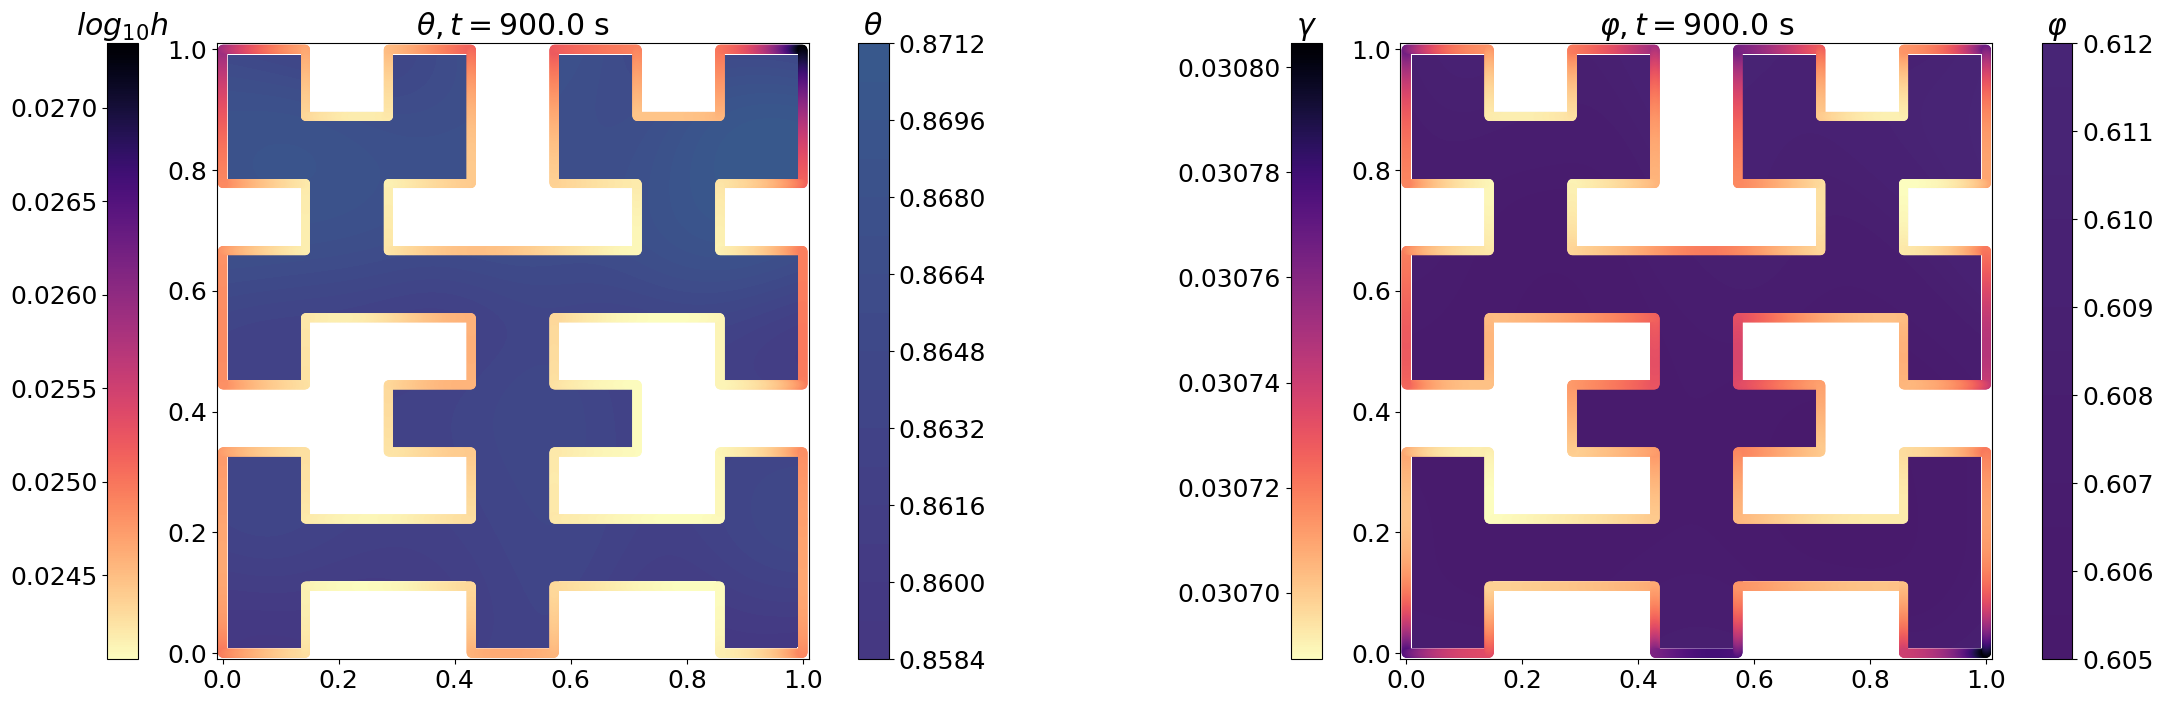

It: 1100 Time: 9.627069473266602 loss_w: 0.125426054 loss: 0.00512041664 J 0.117381342
It: 1200 Time: 8.279852390289307 loss_w: 0.105926119 loss: 0.00501002 J 0.0976055488
It: 1300 Time: 8.270769119262695 loss_w: 0.0836973 loss: 0.00431707036 J 0.076263316
It: 1400 Time: 8.13824987411499 loss_w: 0.0607692935 loss: 0.00362918386 J 0.0544976927
It: 1500 Time: 8.447922945022583 loss_w: 0.0411169901 loss: 0.00299283629 J 0.0357795693
It: 1600 Time: 8.516379833221436 loss_w: 0.026288636 loss: 0.00229984638 J 0.0221014544
It: 1700 Time: 8.60785698890686 loss_w: 0.0165473372 loss: 0.00184284023 J 0.0131393028
It: 1800 Time: 9.434955835342407 loss_w: 0.0107812472 loss: 0.00137987372 J 0.0082144253
It: 1900 Time: 9.046753644943237 loss_w: 0.00760187395 loss: 0.00104418083 J 0.00566974934
It: 2000 Time: 9.138879776000977 loss_w: 0.0058812825 loss: 0.000810817932 J 0.00439952314


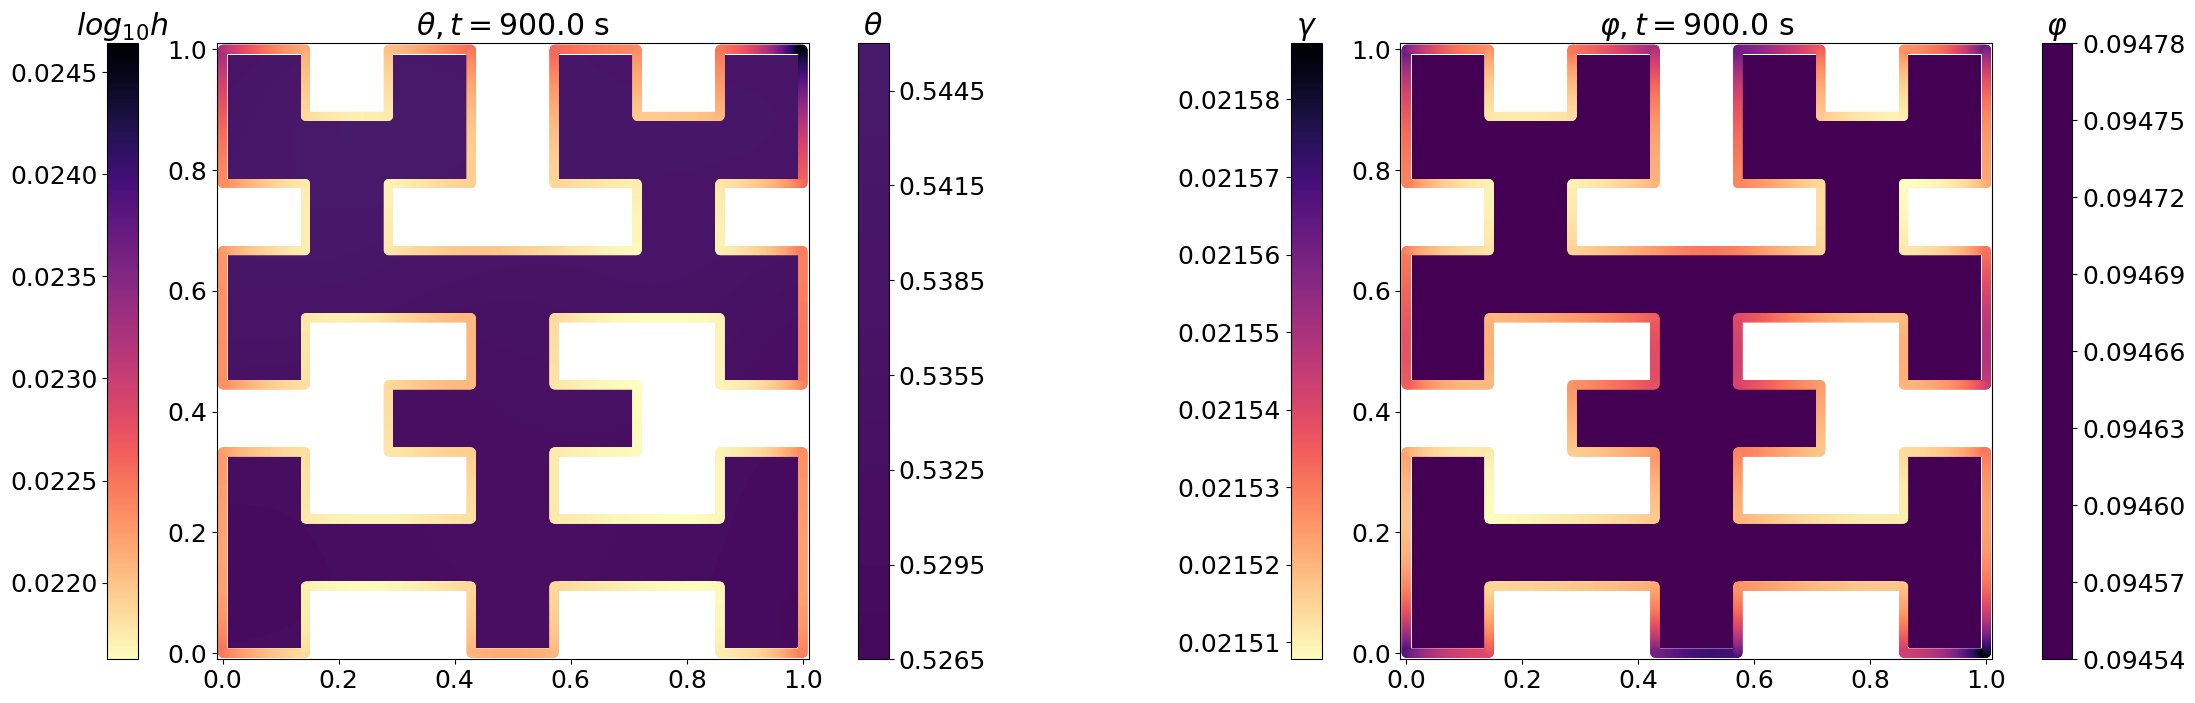

It: 2100 Time: 10.921604871749878 loss_w: 0.00492320955 loss: 0.00066515943 J 0.00372673688
It: 2200 Time: 8.665295600891113 loss_w: 0.00434138067 loss: 0.000579178 J 0.00331295724
It: 2300 Time: 8.54958462715149 loss_w: 0.00394465681 loss: 0.000533342536 J 0.00300099584
It: 2400 Time: 8.977795600891113 loss_w: 0.0036452855 loss: 0.000510229031 J 0.0027381056
It: 2500 Time: 9.164018392562866 loss_w: 0.00340585085 loss: 0.000499193673 J 0.00250877324
It: 2600 Time: 9.252495050430298 loss_w: 0.00320652477 loss: 0.000493890606 J 0.00230590533
It: 2700 Time: 8.912205934524536 loss_w: 0.00303192087 loss: 0.000489759841 J 0.00212385668
It: 2800 Time: 8.807224988937378 loss_w: 0.00286761206 loss: 0.000483063428 J 0.00195724424
It: 2900 Time: 8.630261421203613 loss_w: 0.00270611956 loss: 0.000473934197 J 0.00179947738
It: 3000 Time: 9.448898315429688 loss_w: 0.00255639316 loss: 0.00046771887 J 0.0016453499


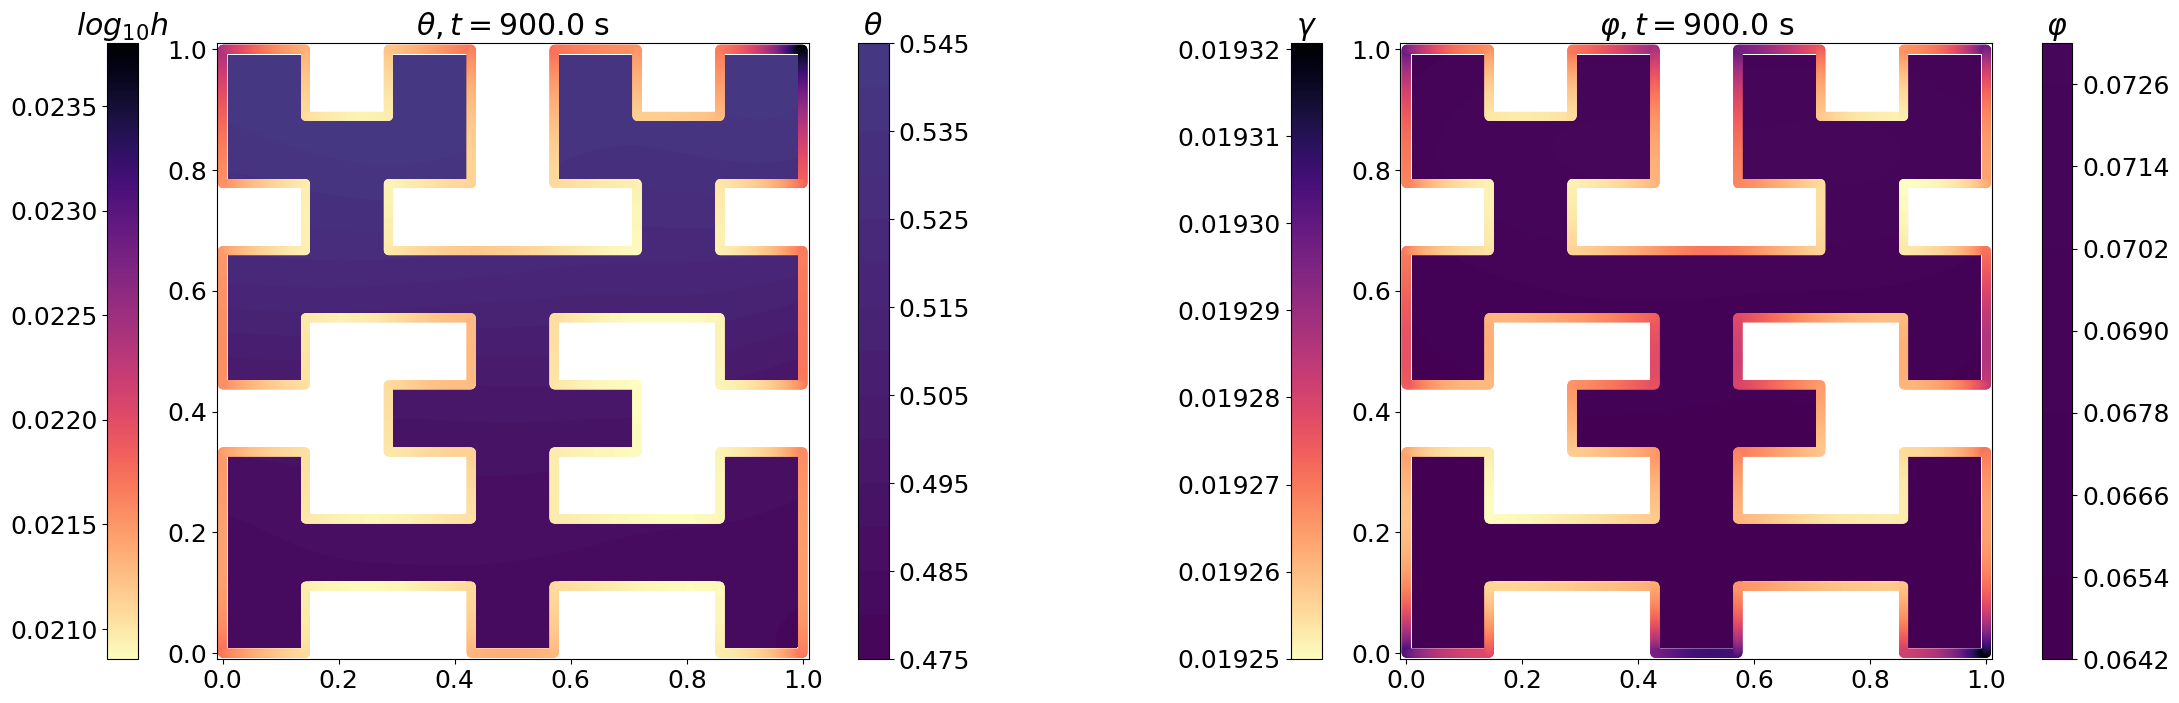

It: 3100 Time: 10.940829753875732 loss_w: 0.00243100035 loss: 0.000466709549 J 0.00149730314
It: 3200 Time: 9.094296932220459 loss_w: 0.00233186688 loss: 0.000465143792 J 0.00136987714
It: 3300 Time: 8.604108333587646 loss_w: 0.00225529214 loss: 0.000456615875 J 0.0012775223
It: 3400 Time: 8.542426109313965 loss_w: 0.00219626073 loss: 0.00044327334 J 0.00121239992
It: 3500 Time: 8.411708116531372 loss_w: 0.00215201778 loss: 0.000429516571 J 0.00116126693
It: 3600 Time: 8.669048070907593 loss_w: 0.00211895863 loss: 0.000415547751 J 0.00112052425
It: 3700 Time: 8.59012746810913 loss_w: 0.00209625252 loss: 0.000400500227 J 0.00109256653
It: 3800 Time: 8.94359803199768 loss_w: 0.00208115764 loss: 0.000385195948 J 0.00107349432
It: 3900 Time: 8.641818284988403 loss_w: 0.00207164558 loss: 0.000369926158 J 0.00106105127
It: 4000 Time: 8.682851791381836 loss_w: 0.00206806231 loss: 0.000354788208 J 0.00105608918


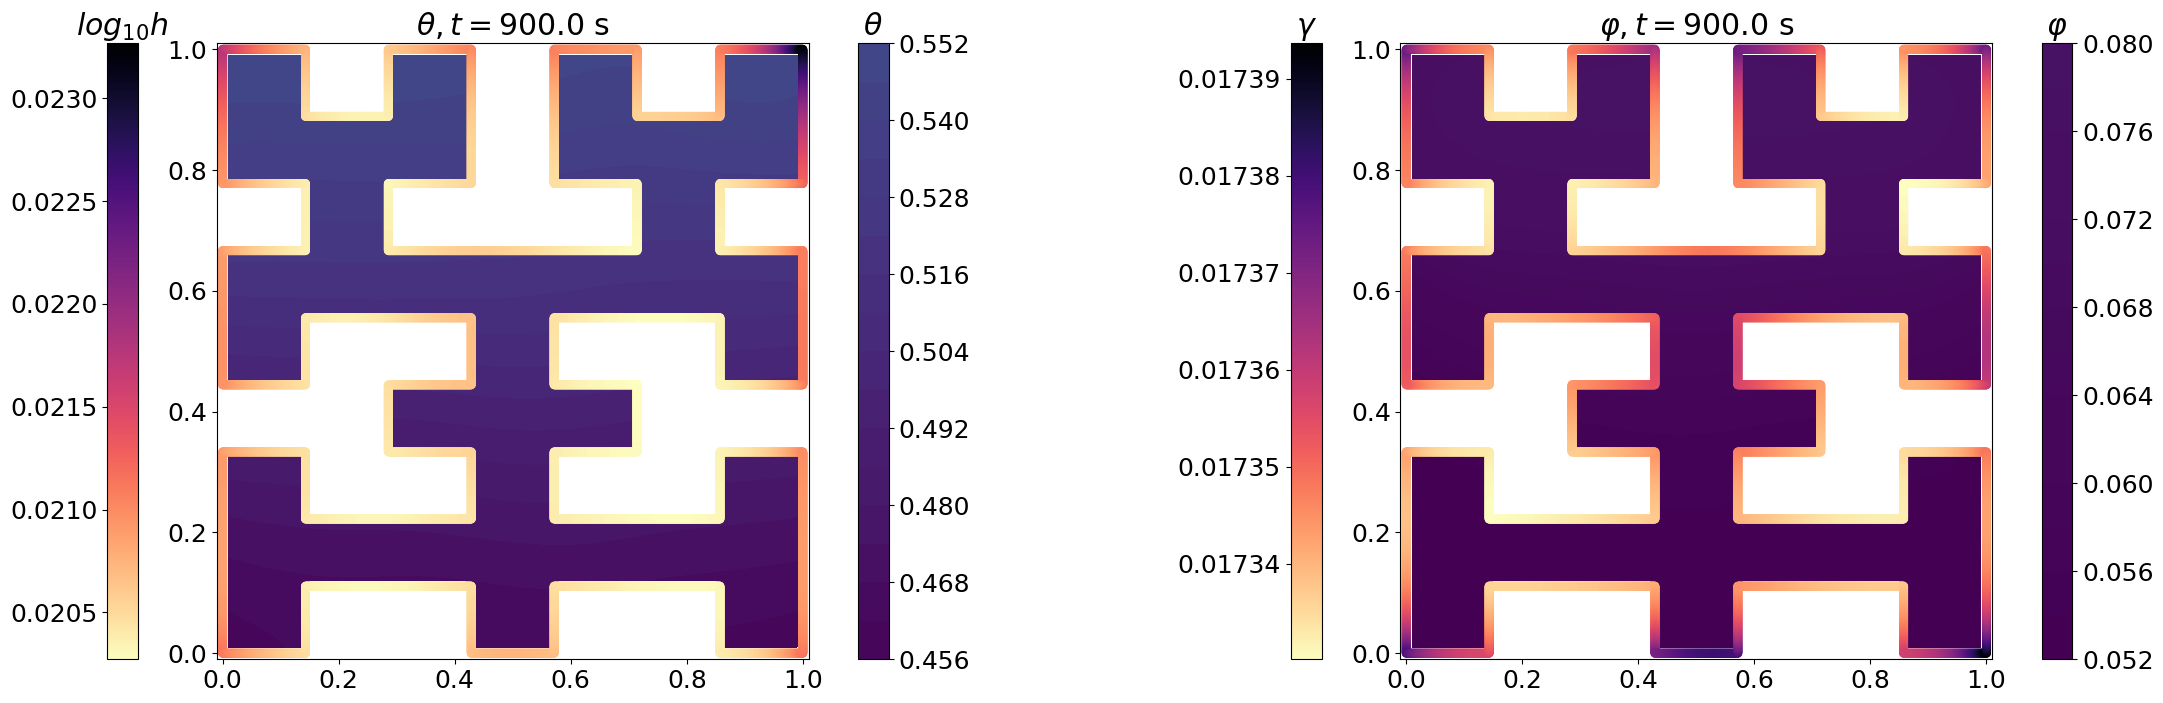

It: 4100 Time: 10.076833248138428 loss_w: 0.00206737057 loss: 0.000340245664 J 0.00105502328
It: 4200 Time: 8.538484811782837 loss_w: 0.00207039947 loss: 0.000326575362 J 0.00105772121
It: 4300 Time: 8.387480735778809 loss_w: 0.0020753378 loss: 0.000313584489 J 0.00106341543
It: 4400 Time: 8.463621377944946 loss_w: 0.00208173972 loss: 0.000301509863 J 0.00107048964
It: 4500 Time: 8.605213165283203 loss_w: 0.00209039496 loss: 0.000290128199 J 0.00108087494
It: 4600 Time: 8.555305004119873 loss_w: 0.00209949631 loss: 0.000279626343 J 0.00109133497
It: 4700 Time: 8.580977201461792 loss_w: 0.00210974365 loss: 0.000269807351 J 0.0011036034
It: 4800 Time: 8.51596999168396 loss_w: 0.00211996213 loss: 0.000260589295 J 0.00111657777
It: 4900 Time: 8.463741540908813 loss_w: 0.00212943414 loss: 0.000252234982 J 0.00112813083
It: 5000 Time: 8.881538152694702 loss_w: 0.00213832362 loss: 0.00024427686 J 0.00114037783


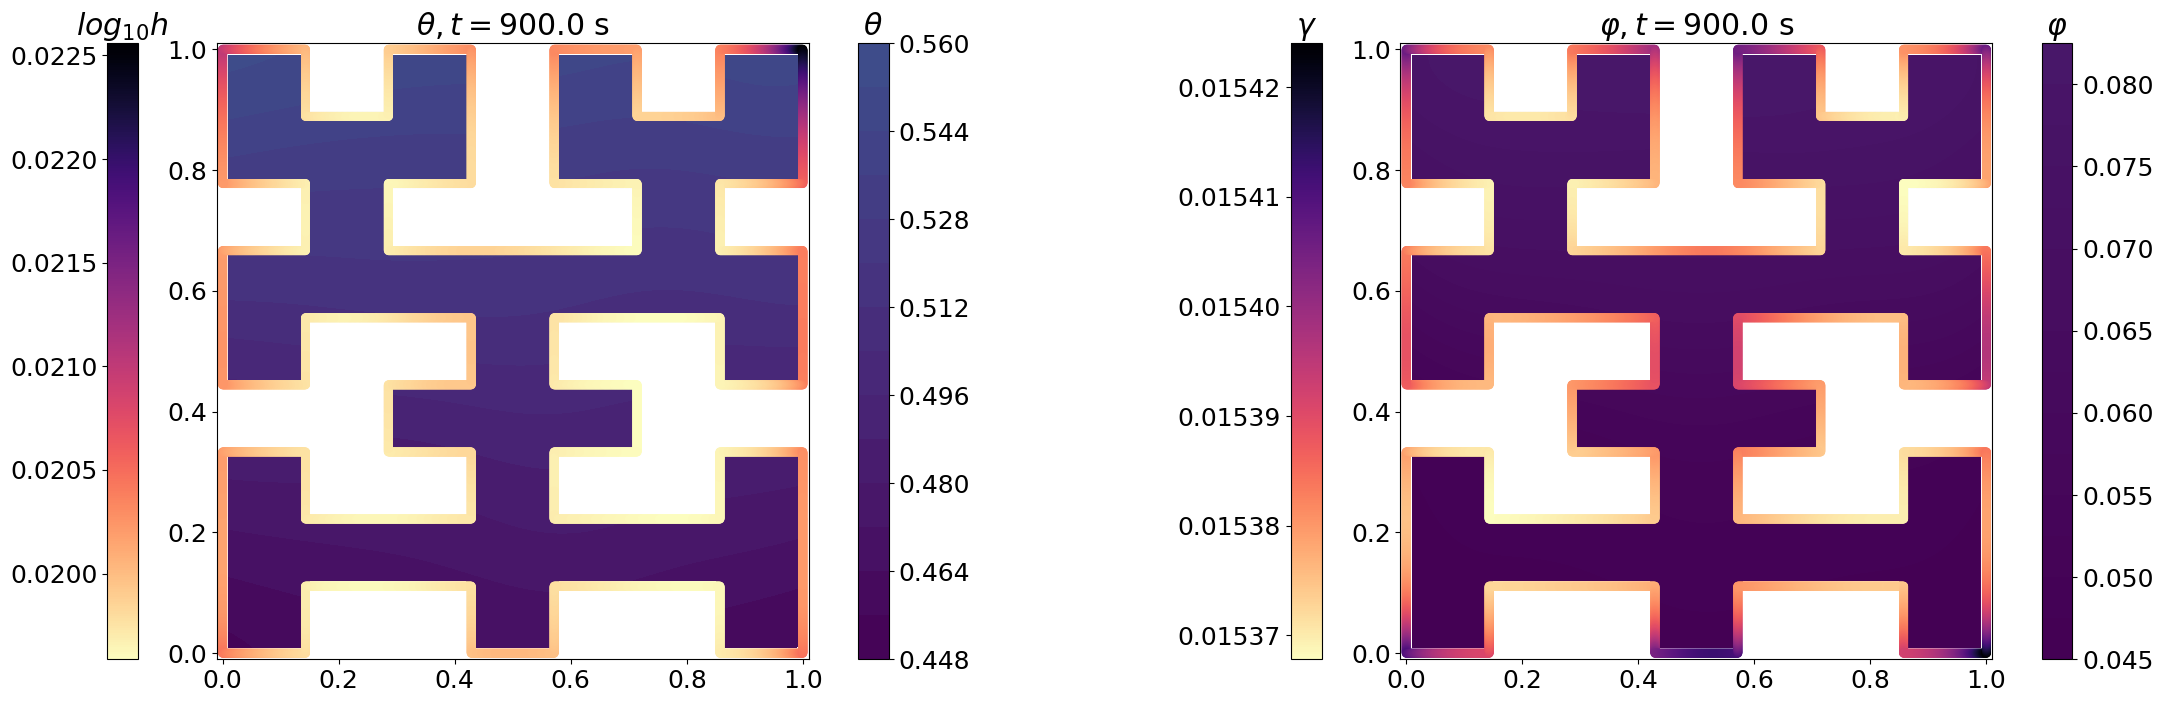

It: 5100 Time: 10.390592813491821 loss_w: 0.00214813277 loss: 0.000237250191 J 0.00115282764
It: 5200 Time: 8.81491994857788 loss_w: 0.00215607 loss: 0.000230678939 J 0.00116340839
It: 5300 Time: 8.601608991622925 loss_w: 0.00216349587 loss: 0.000224769799 J 0.00117326365
It: 5400 Time: 8.871547222137451 loss_w: 0.00217062654 loss: 0.000219377107 J 0.00118298421
It: 5500 Time: 8.902735471725464 loss_w: 0.00217650156 loss: 0.000214674365 J 0.00119008962
It: 5600 Time: 8.667609453201294 loss_w: 0.00218068017 loss: 0.000210447484 J 0.00119568908
It: 5700 Time: 8.613299131393433 loss_w: 0.0021846937 loss: 0.000206616722 J 0.00120108016
It: 5800 Time: 8.654432773590088 loss_w: 0.00218669046 loss: 0.000203250922 J 0.00120320683
It: 5900 Time: 8.481375455856323 loss_w: 0.00218752166 loss: 0.000200196911 J 0.00120405795
It: 6000 Time: 8.56266164779663 loss_w: 0.00218721433 loss: 0.000197400543 J 0.00120339857


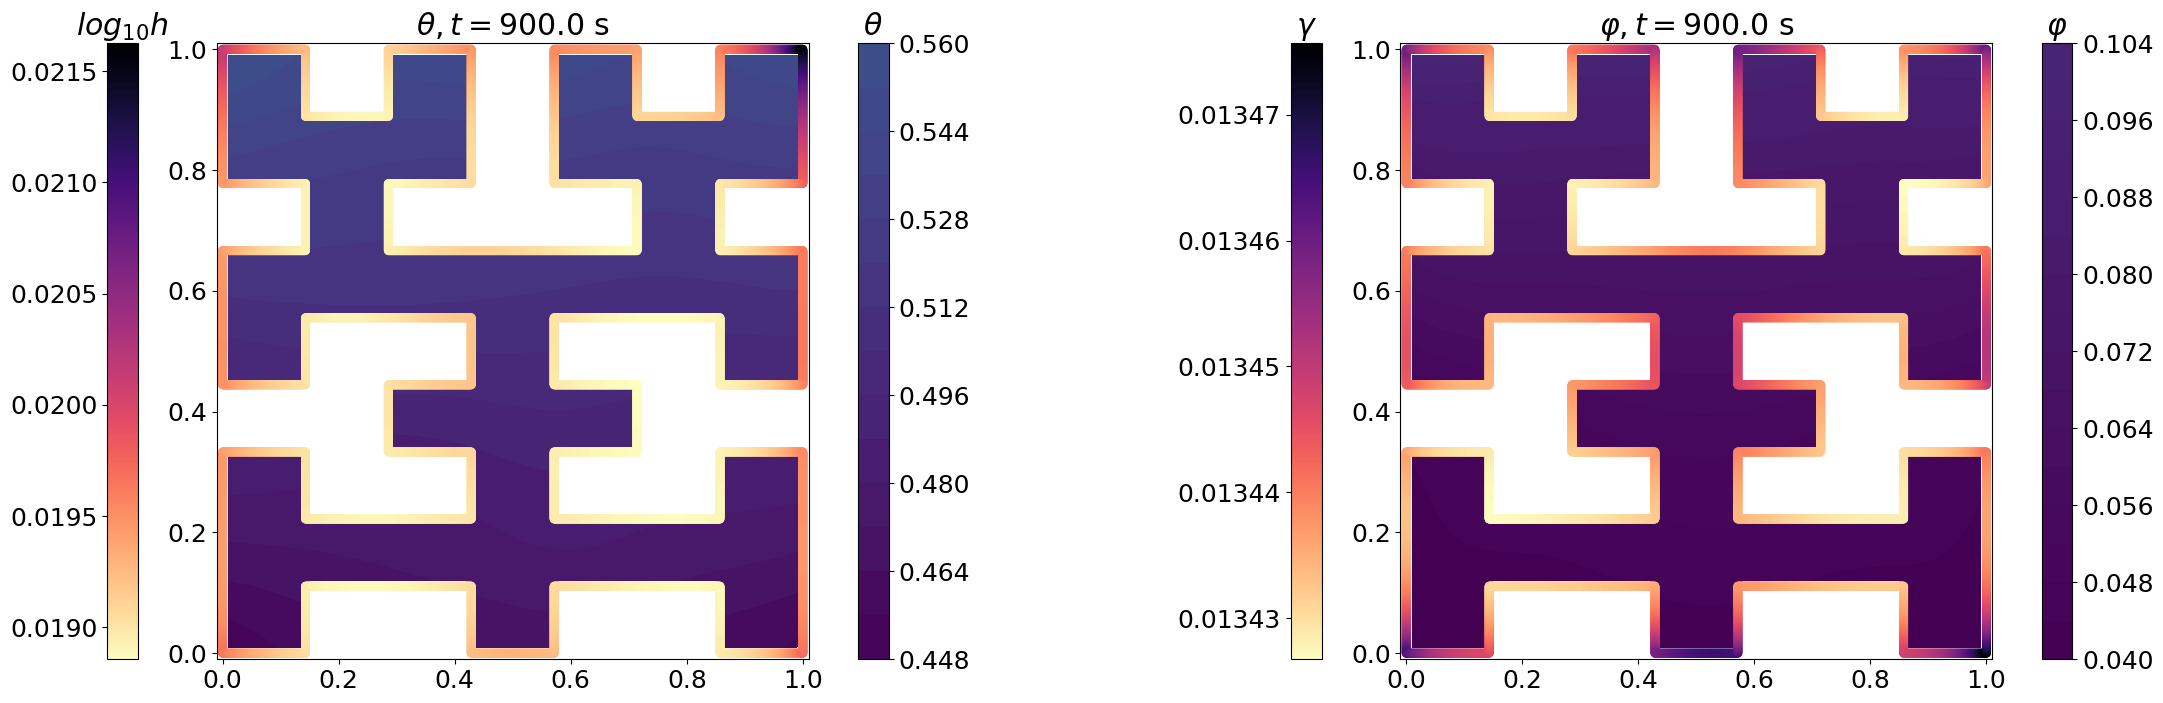

It: 6100 Time: 11.573997497558594 loss_w: 0.00218477286 loss: 0.00019487807 J 0.00120101485
It: 6200 Time: 9.044198036193848 loss_w: 0.0021816981 loss: 0.000192785606 J 0.00119823043
It: 6300 Time: 8.986122131347656 loss_w: 0.00217816886 loss: 0.000190616964 J 0.00119568571
It: 6400 Time: 8.961193084716797 loss_w: 0.00217074924 loss: 0.000188823979 J 0.00118913455
It: 6500 Time: 8.834707498550415 loss_w: 0.00216205604 loss: 0.000187300568 J 0.00118220958
It: 6600 Time: 8.855690717697144 loss_w: 0.0021509442 loss: 0.000186306774 J 0.00117261789
It: 6700 Time: 8.706601619720459 loss_w: 0.002138271 loss: 0.000185102457 J 0.00116165169
It: 6800 Time: 8.612335681915283 loss_w: 0.00212400919 loss: 0.000184270073 J 0.00114947476
It: 6900 Time: 8.565831422805786 loss_w: 0.00210611033 loss: 0.00018379066 J 0.00113347522
It: 7000 Time: 8.53868293762207 loss_w: 0.00208757212 loss: 0.000183229233 J 0.00111732166


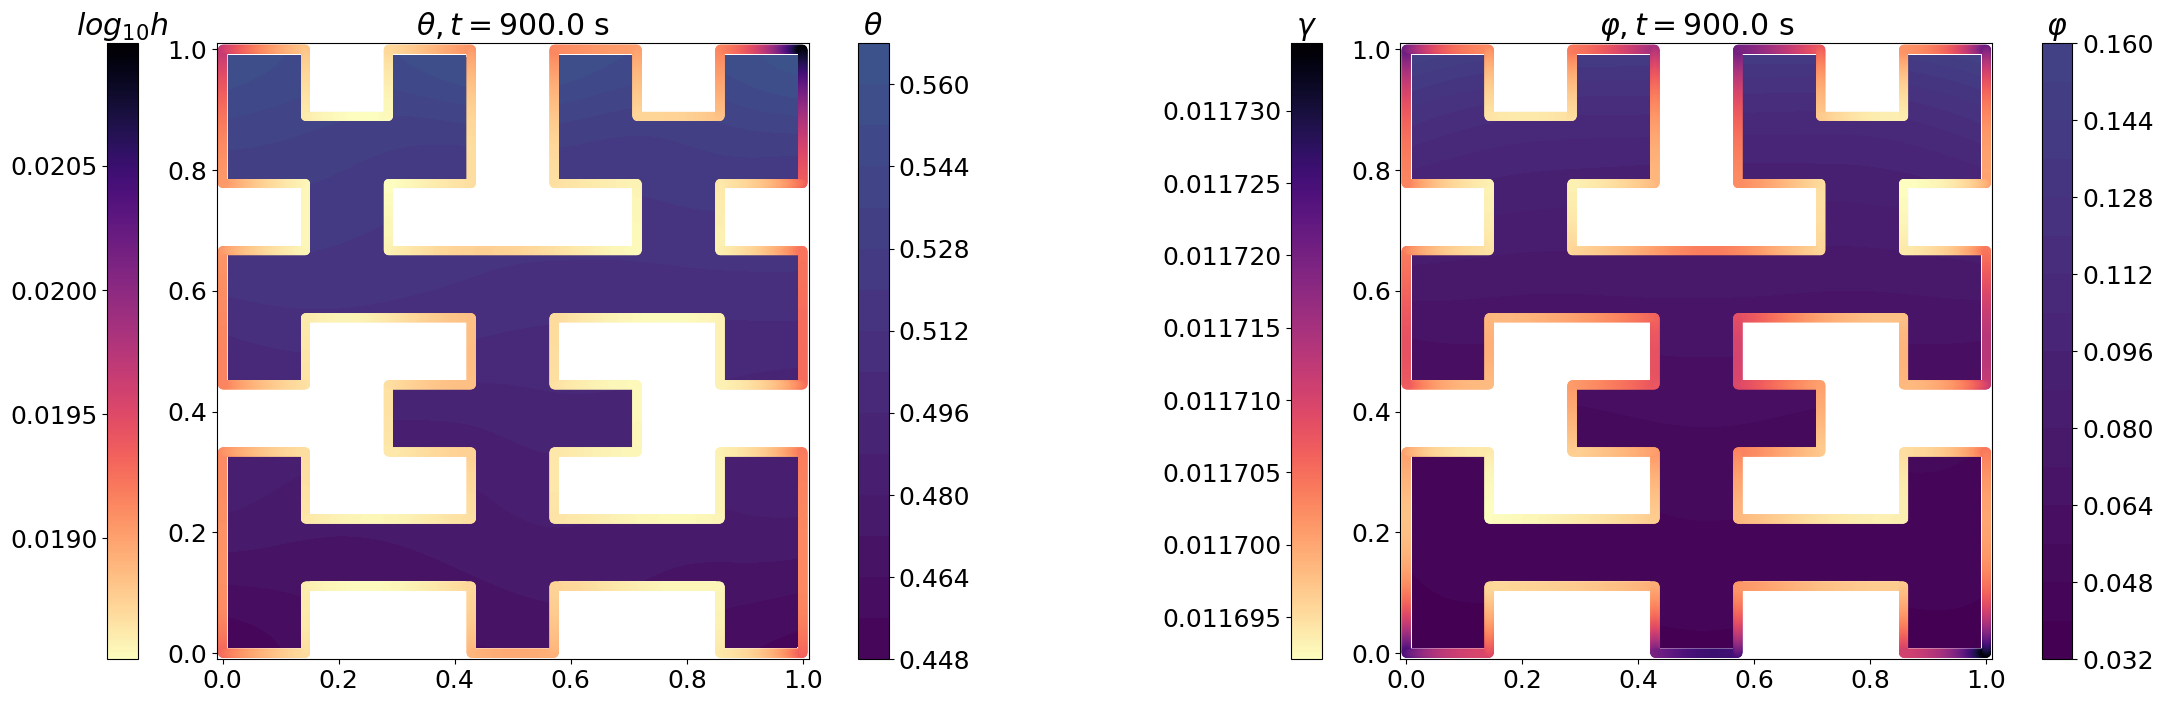

It: 7100 Time: 10.201879024505615 loss_w: 0.00206701737 loss: 0.000182666074 J 0.00110022165
It: 7200 Time: 9.359628915786743 loss_w: 0.0020473022 loss: 0.000181784708 J 0.00108246563
It: 7300 Time: 9.24598503112793 loss_w: 0.00202870322 loss: 0.000180953662 J 0.00106784084
It: 7400 Time: 9.518315553665161 loss_w: 0.00200969796 loss: 0.000179997194 J 0.00105149753
It: 7500 Time: 9.111305475234985 loss_w: 0.00199269364 loss: 0.000178323375 J 0.00103742653
It: 7600 Time: 8.724607467651367 loss_w: 0.00197603041 loss: 0.000176918125 J 0.00102378719
It: 7700 Time: 8.65550947189331 loss_w: 0.0019590857 loss: 0.000175421388 J 0.00101087324
It: 7800 Time: 9.141036987304688 loss_w: 0.00194191327 loss: 0.000174301938 J 0.000996496761
It: 7900 Time: 9.427399635314941 loss_w: 0.00192345027 loss: 0.000173587017 J 0.000981915
It: 8000 Time: 9.20445442199707 loss_w: 0.00190357445 loss: 0.000173262684 J 0.000964658684


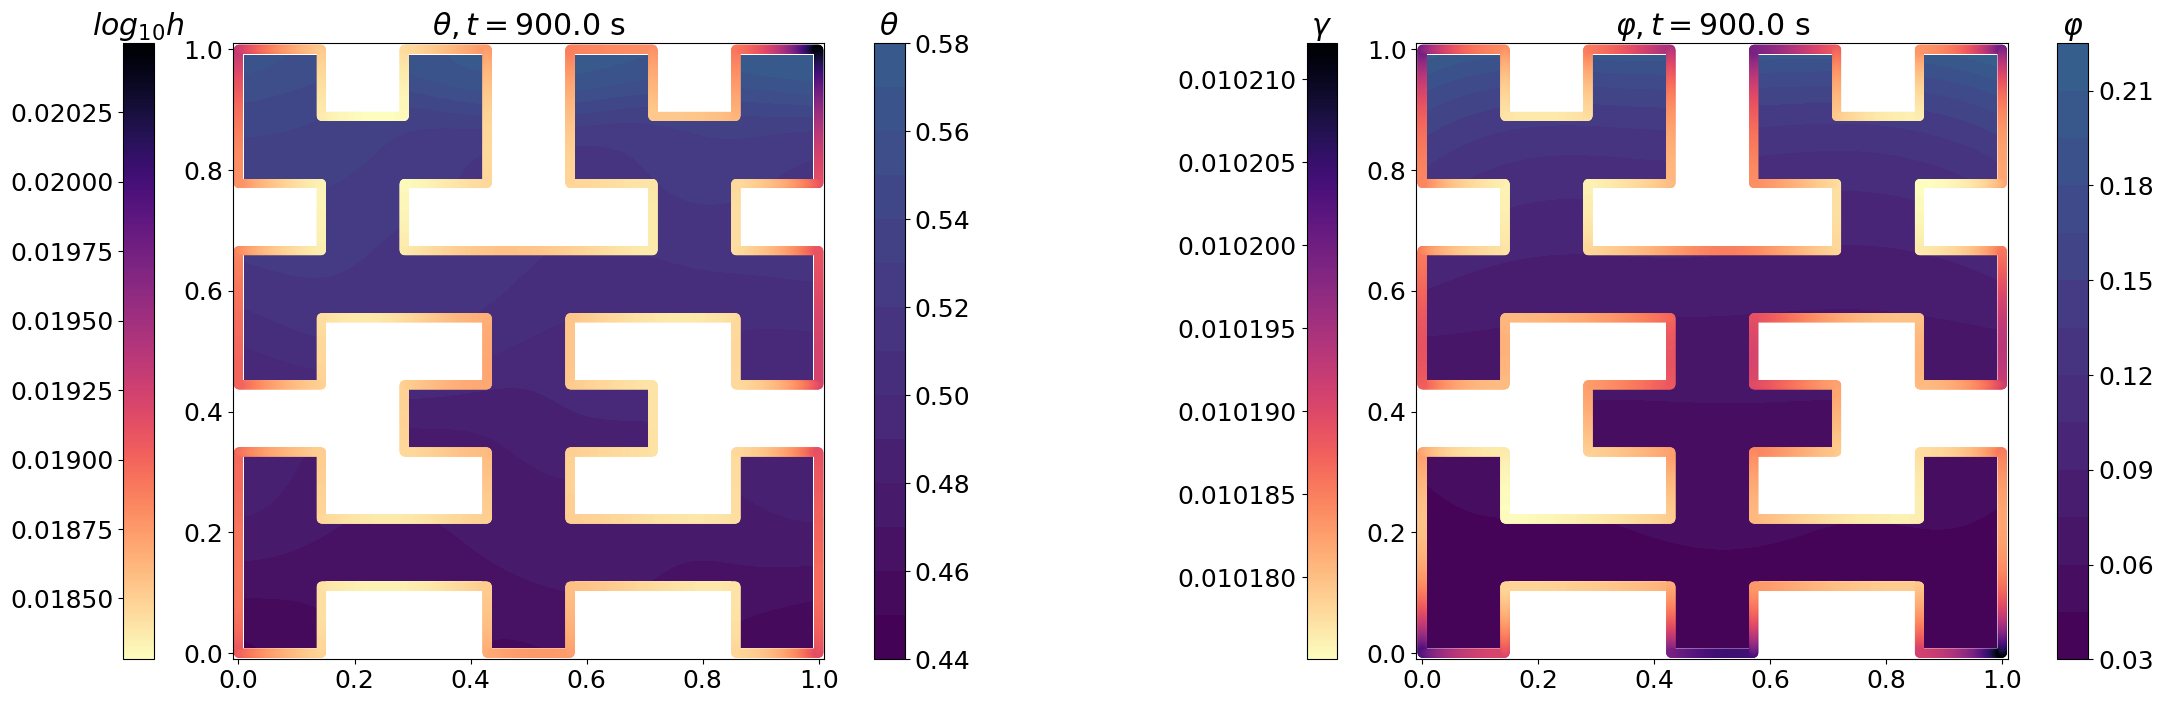

It: 8100 Time: 10.175244331359863 loss_w: 0.00188120583 loss: 0.000173209934 J 0.000944353174
It: 8200 Time: 9.076222658157349 loss_w: 0.00185865 loss: 0.000172888831 J 0.00092415628
It: 8300 Time: 8.849730014801025 loss_w: 0.0018348156 loss: 0.000172428248 J 0.000903354
It: 8400 Time: 8.903447151184082 loss_w: 0.0018095444 loss: 0.000170475818 J 0.000880501233
It: 8500 Time: 8.936665296554565 loss_w: 0.00178568903 loss: 0.000168282117 J 0.000860687927
It: 8600 Time: 8.552043199539185 loss_w: 0.00176258909 loss: 0.000165092599 J 0.000841469
It: 8700 Time: 8.894095420837402 loss_w: 0.00174311118 loss: 0.000162072538 J 0.000828585937
It: 8800 Time: 8.80945372581482 loss_w: 0.00172316458 loss: 0.000158331139 J 0.000815494801
It: 8900 Time: 9.525324821472168 loss_w: 0.00170432311 loss: 0.000154341527 J 0.000806992059
It: 9000 Time: 9.005861759185791 loss_w: 0.00168373482 loss: 0.000150506676 J 0.000796125445


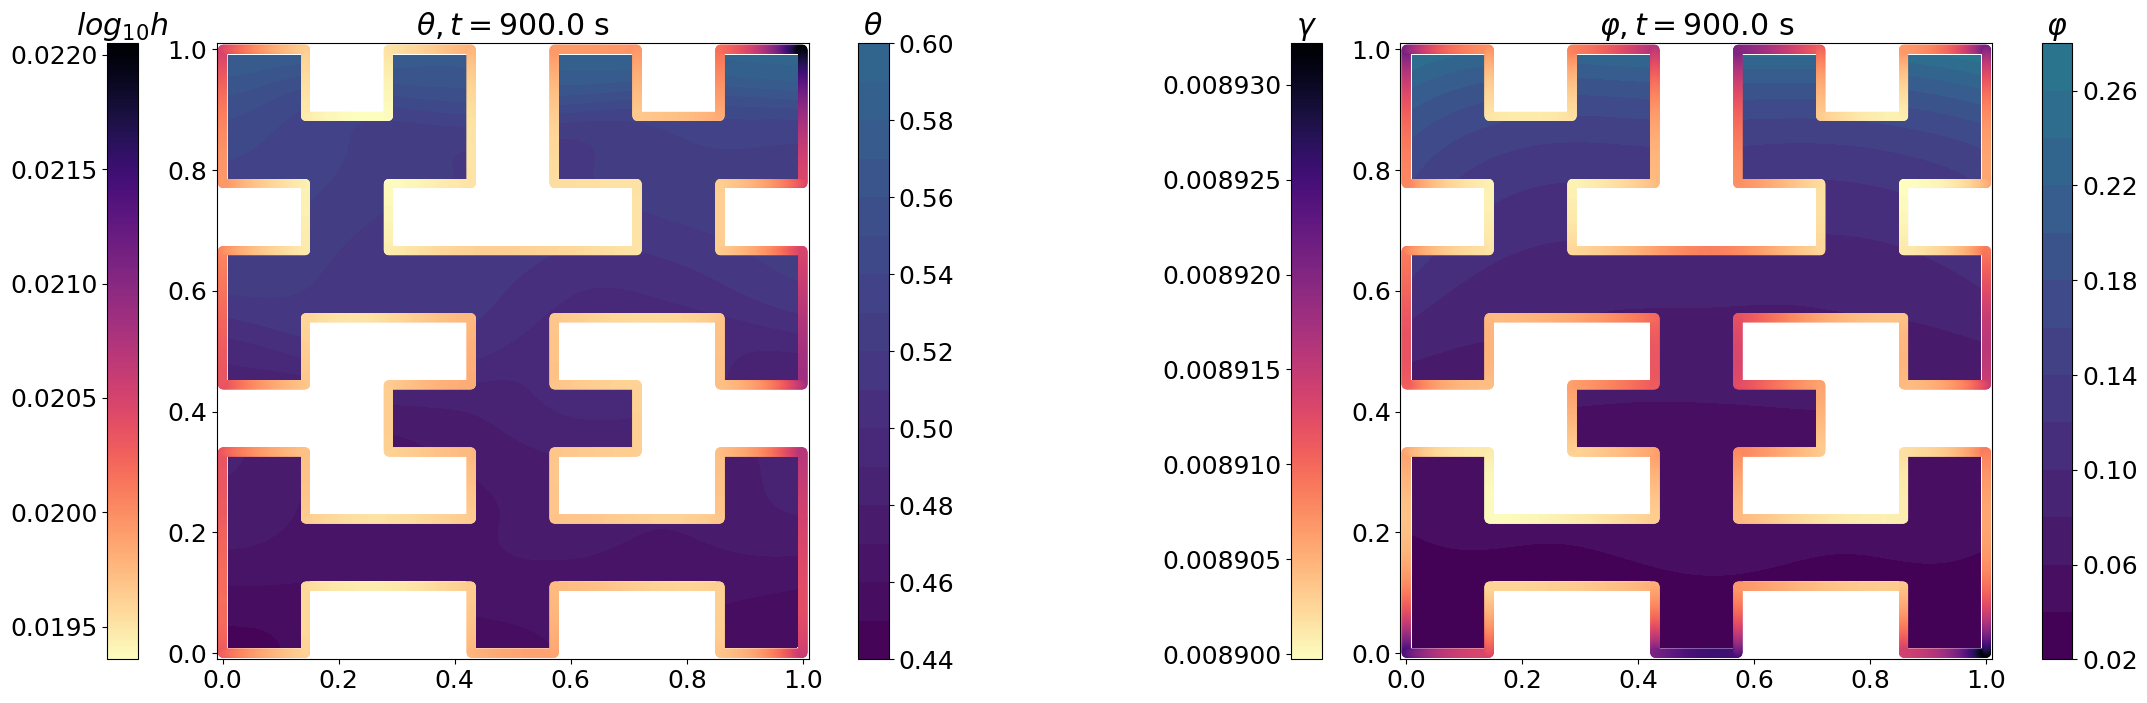

It: 9100 Time: 9.96578860282898 loss_w: 0.00166368275 loss: 0.000147120838 J 0.000782860268
It: 9200 Time: 8.610281944274902 loss_w: 0.00164329 loss: 0.000143791491 J 0.000770442071
It: 9300 Time: 9.14547085762024 loss_w: 0.00162385707 loss: 0.000141337077 J 0.000758626
It: 9400 Time: 9.093839645385742 loss_w: 0.00160566275 loss: 0.000138736708 J 0.000745980302
It: 9500 Time: 9.078578233718872 loss_w: 0.00158809568 loss: 0.000136116505 J 0.000732658489
It: 9600 Time: 8.733835935592651 loss_w: 0.001573749 loss: 0.000134093527 J 0.00072137278
It: 9700 Time: 8.638951301574707 loss_w: 0.00156229711 loss: 0.000132556233 J 0.00071027549
It: 9800 Time: 8.72209119796753 loss_w: 0.00155297632 loss: 0.000130525674 J 0.000700333156
It: 9900 Time: 8.802838802337646 loss_w: 0.00154386531 loss: 0.00012897329 J 0.00069252064
It: 10000 Time: 8.995572328567505 loss_w: 0.00153331994 loss: 0.000126486702 J 0.000683066901


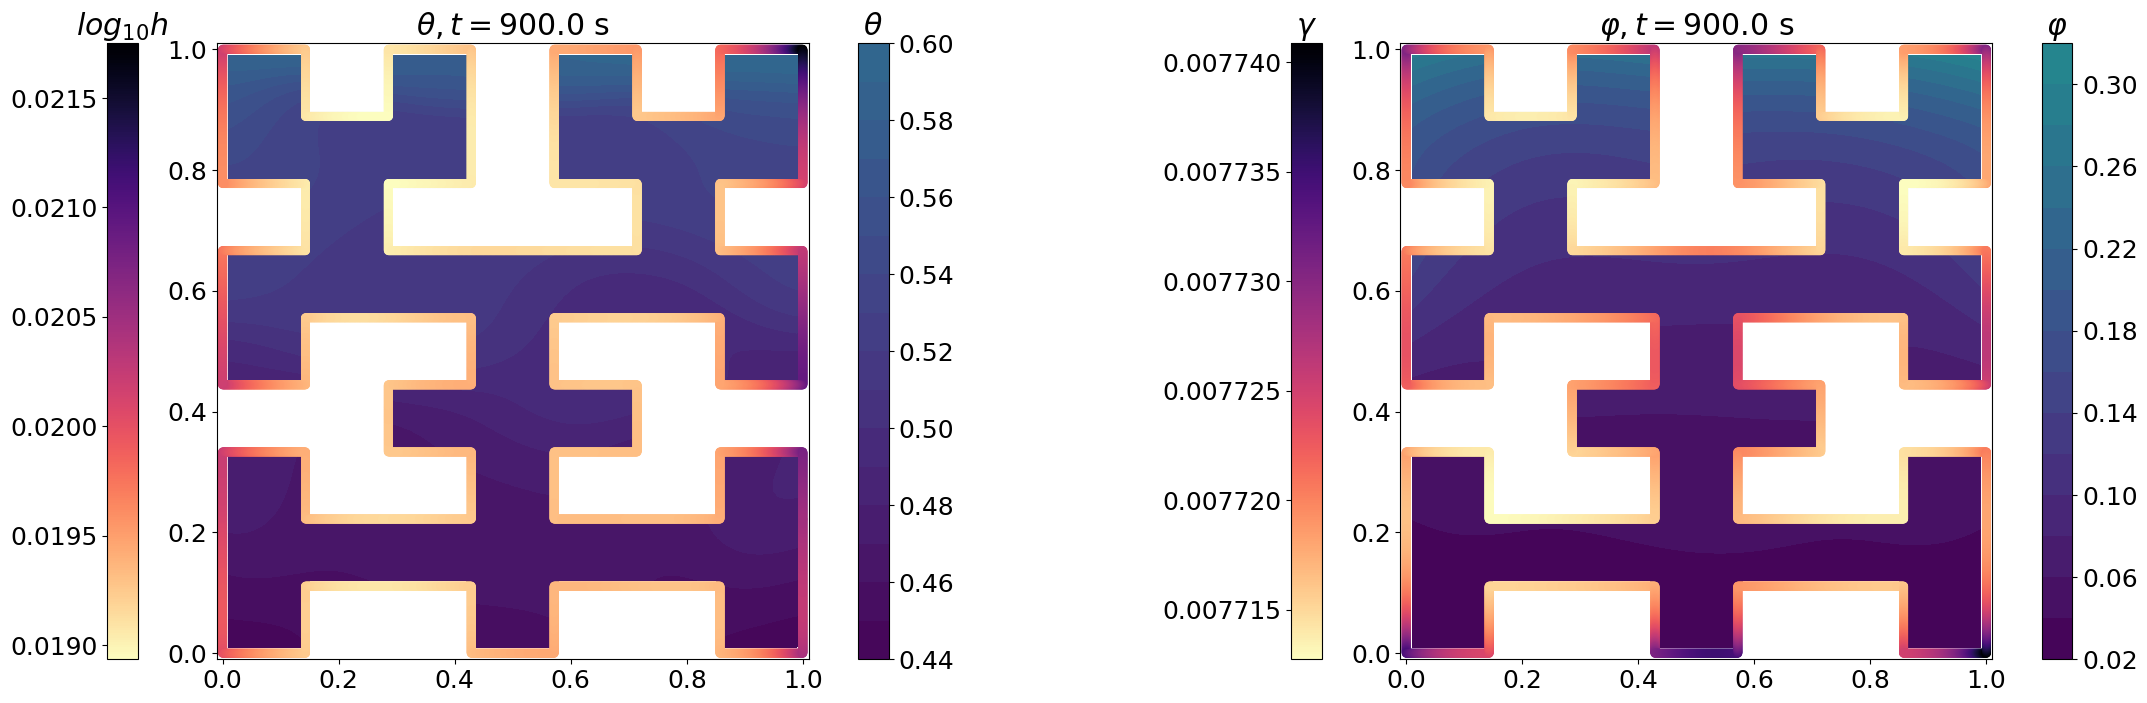

It: 10100 Time: 11.02856993675232 loss_w: 0.00151874963 loss: 0.000125386578 J 0.0006710944
It: 10200 Time: 8.778701543807983 loss_w: 0.00150319736 loss: 0.000123797217 J 0.000656804536
It: 10300 Time: 8.356284856796265 loss_w: 0.00148745859 loss: 0.000122046964 J 0.000644683198
It: 10400 Time: 8.517488956451416 loss_w: 0.00147448364 loss: 0.000120355879 J 0.000636746874
It: 10500 Time: 8.485489845275879 loss_w: 0.00146018737 loss: 0.000117283897 J 0.000627872883
It: 10600 Time: 8.421181201934814 loss_w: 0.00144591392 loss: 0.000115137787 J 0.000616390142
It: 10700 Time: 8.362948179244995 loss_w: 0.00142872892 loss: 0.000113581365 J 0.000601900625
It: 10800 Time: 8.539658546447754 loss_w: 0.00140737183 loss: 0.000112391353 J 0.000585866568
It: 10900 Time: 8.756625413894653 loss_w: 0.00137780258 loss: 0.00011148589 J 0.000563738227
It: 11000 Time: 9.353349924087524 loss_w: 0.00134034548 loss: 0.000111669622 J 0.000537221378


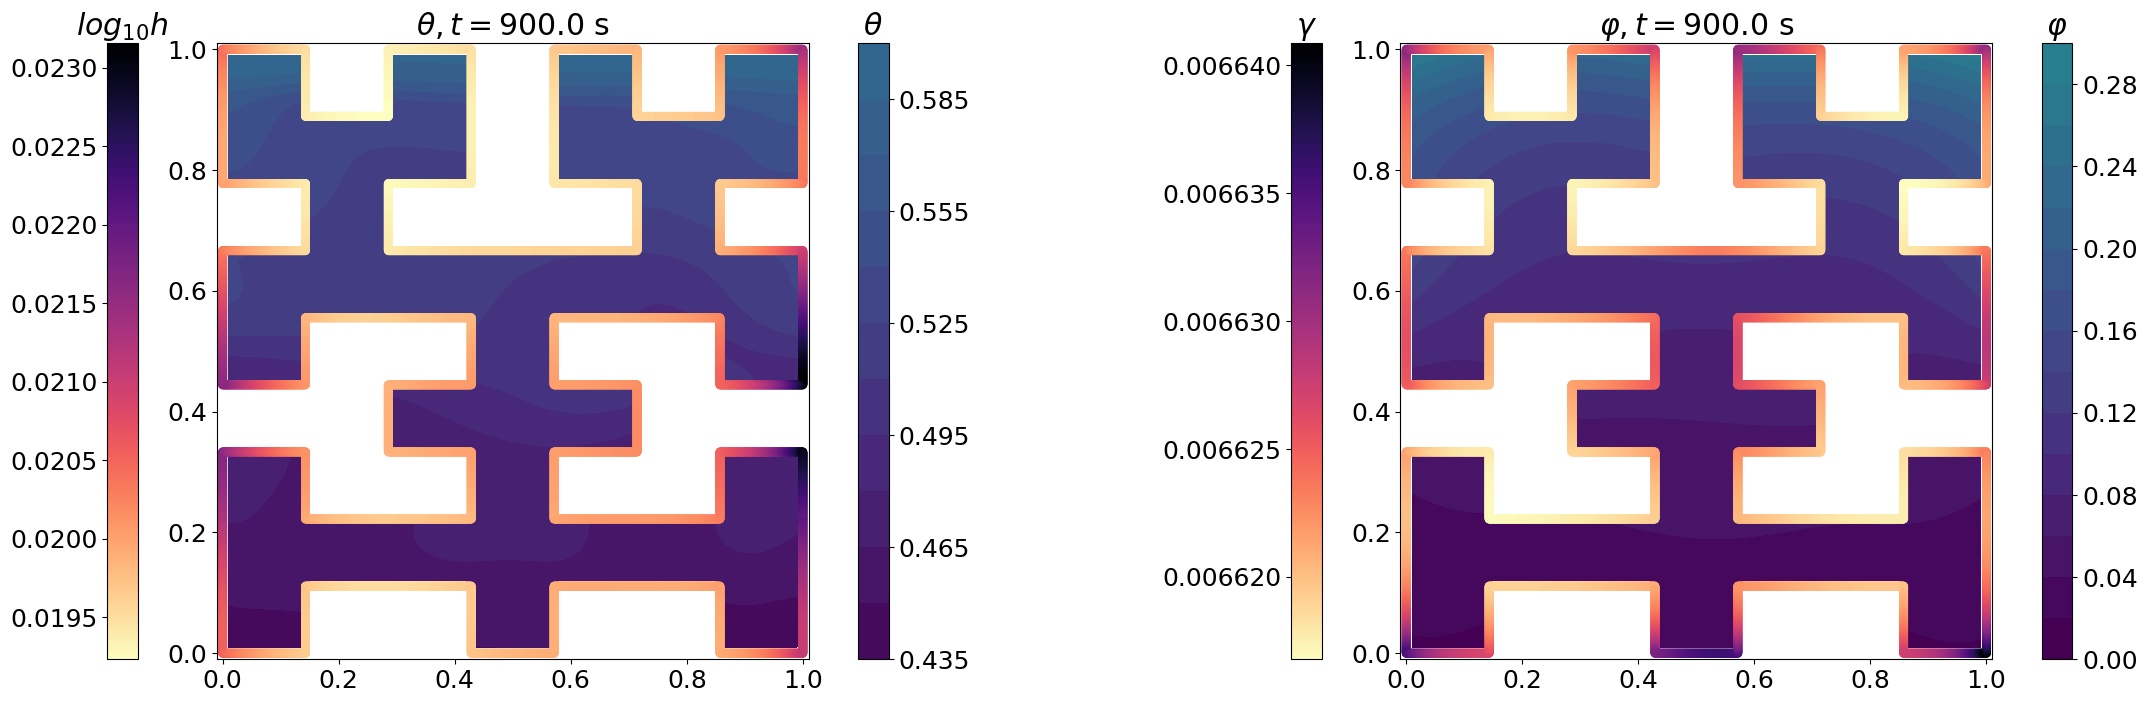

It: 11100 Time: 10.101271390914917 loss_w: 0.00129506167 loss: 0.000112404872 J 0.000504775
It: 11200 Time: 8.9104642868042 loss_w: 0.00124762475 loss: 0.000112946349 J 0.000469389168
It: 11300 Time: 8.83019733428955 loss_w: 0.00119962497 loss: 0.000112680471 J 0.000431577326
It: 11400 Time: 8.527848243713379 loss_w: 0.00115284743 loss: 0.000111892499 J 0.000397832249
It: 11500 Time: 8.543042182922363 loss_w: 0.00110027043 loss: 0.000110724046 J 0.000365372485
It: 11600 Time: 8.597599506378174 loss_w: 0.00103490974 loss: 0.000108759312 J 0.000326336
It: 11700 Time: 8.398244142532349 loss_w: 0.000951701542 loss: 0.00010847173 J 0.000274305377
It: 11800 Time: 8.52289628982544 loss_w: 0.000869741431 loss: 0.000107359978 J 0.000228588135
It: 11900 Time: 8.60048794746399 loss_w: 0.000803729752 loss: 0.000105522493 J 0.000197821471
It: 12000 Time: 8.483751058578491 loss_w: 0.0007492117 loss: 0.000102335245 J 0.000175354377


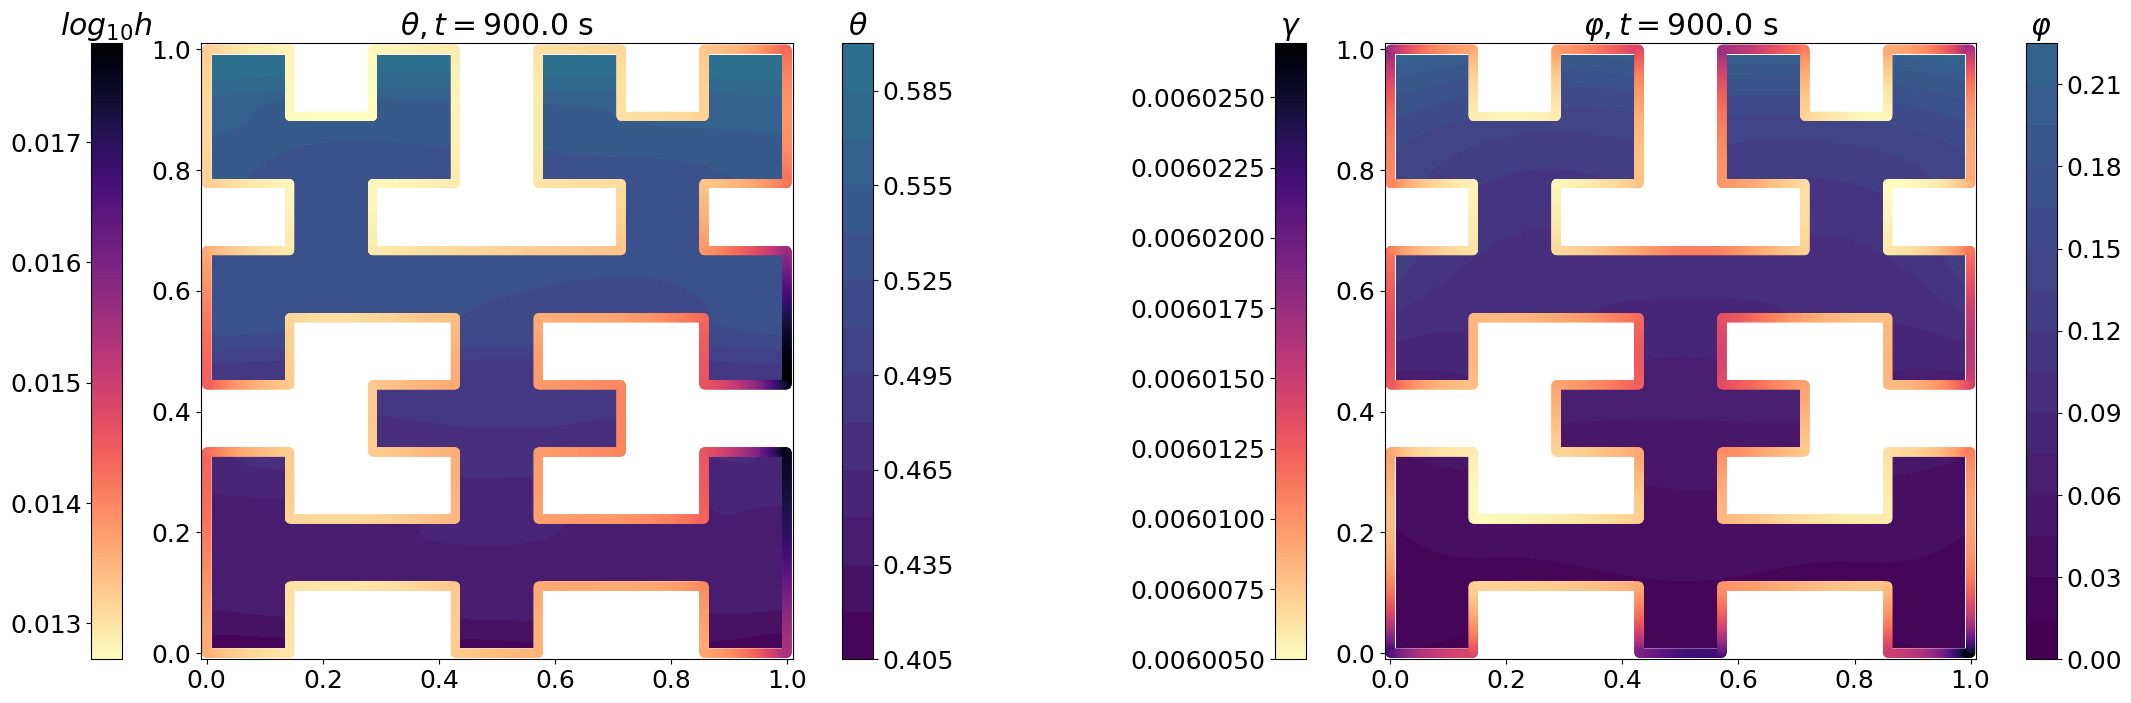

It: 12100 Time: 10.418456077575684 loss_w: 0.000701090437 loss: 9.95824666e-05 J 0.000157232891


KeyboardInterrupt: 

In [14]:
train.fit(30000)

It: 0 Time: 0.2916271686553955 loss_w: 0.0006720128 loss: 9.72436101e-05 J 0.000146471983
It: 100 Time: 7.792260408401489 loss_w: 0.000630495138 loss: 9.45104621e-05 J 0.000130595567
It: 200 Time: 7.68487024307251 loss_w: 0.000592773082 loss: 9.3062059e-05 J 0.000115424991
It: 300 Time: 7.7421228885650635 loss_w: 0.000555396779 loss: 9.12846153e-05 J 0.000100974888
It: 400 Time: 7.9218244552612305 loss_w: 0.000520250935 loss: 8.92557364e-05 J 8.60559085e-05
It: 500 Time: 7.909330129623413 loss_w: 0.000490258273 loss: 8.62894522e-05 J 7.50339386e-05
It: 600 Time: 8.121508598327637 loss_w: 0.000464516459 loss: 8.38096603e-05 J 6.61612576e-05
It: 700 Time: 8.696474552154541 loss_w: 0.00044171745 loss: 8.26044052e-05 J 5.75711383e-05
It: 800 Time: 8.395671606063843 loss_w: 0.000421695207 loss: 8.0397e-05 J 4.97514884e-05
It: 900 Time: 8.272223949432373 loss_w: 0.000406096631 loss: 7.85250522e-05 J 4.39123833e-05
It: 1000 Time: 8.243578672409058 loss_w: 0.000391726702 loss: 7.70153056e-05 J

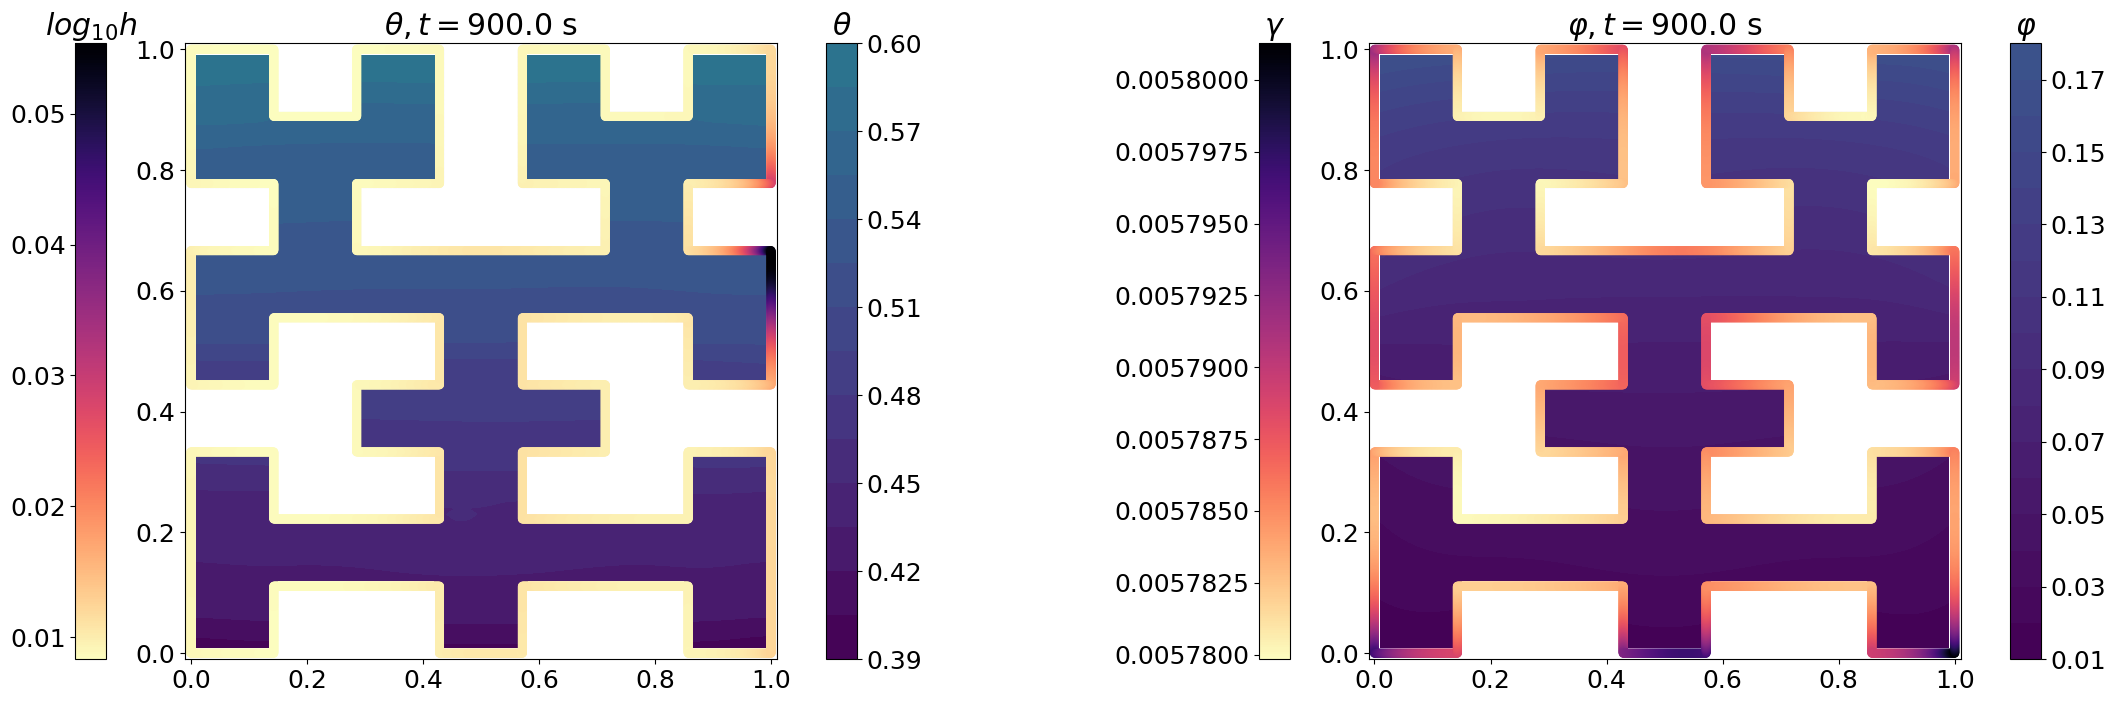

It: 1100 Time: 9.827103614807129 loss_w: 0.000380094512 loss: 7.52575652e-05 J 3.54356707e-05
It: 1200 Time: 8.509644269943237 loss_w: 0.000369350659 loss: 7.30804e-05 J 3.22443e-05
It: 1300 Time: 8.545832872390747 loss_w: 0.000359864207 loss: 7.08078442e-05 J 2.96437611e-05
It: 1400 Time: 8.771219968795776 loss_w: 0.000352231931 loss: 6.86317289e-05 J 2.74630911e-05
It: 1500 Time: 9.392317533493042 loss_w: 0.000343370019 loss: 6.68336288e-05 J 2.56860494e-05
It: 1600 Time: 9.627392768859863 loss_w: 0.000336182216 loss: 6.48155547e-05 J 2.39413475e-05
It: 1700 Time: 8.621353387832642 loss_w: 0.000328553404 loss: 6.30199938e-05 J 2.22787185e-05
It: 1800 Time: 8.944122076034546 loss_w: 0.000322043343 loss: 6.14269738e-05 J 2.11779225e-05
It: 1900 Time: 8.526023387908936 loss_w: 0.000316587888 loss: 6.06836184e-05 J 1.99305287e-05
It: 2000 Time: 8.520819902420044 loss_w: 0.000311331882 loss: 5.86533715e-05 J 1.90071241e-05


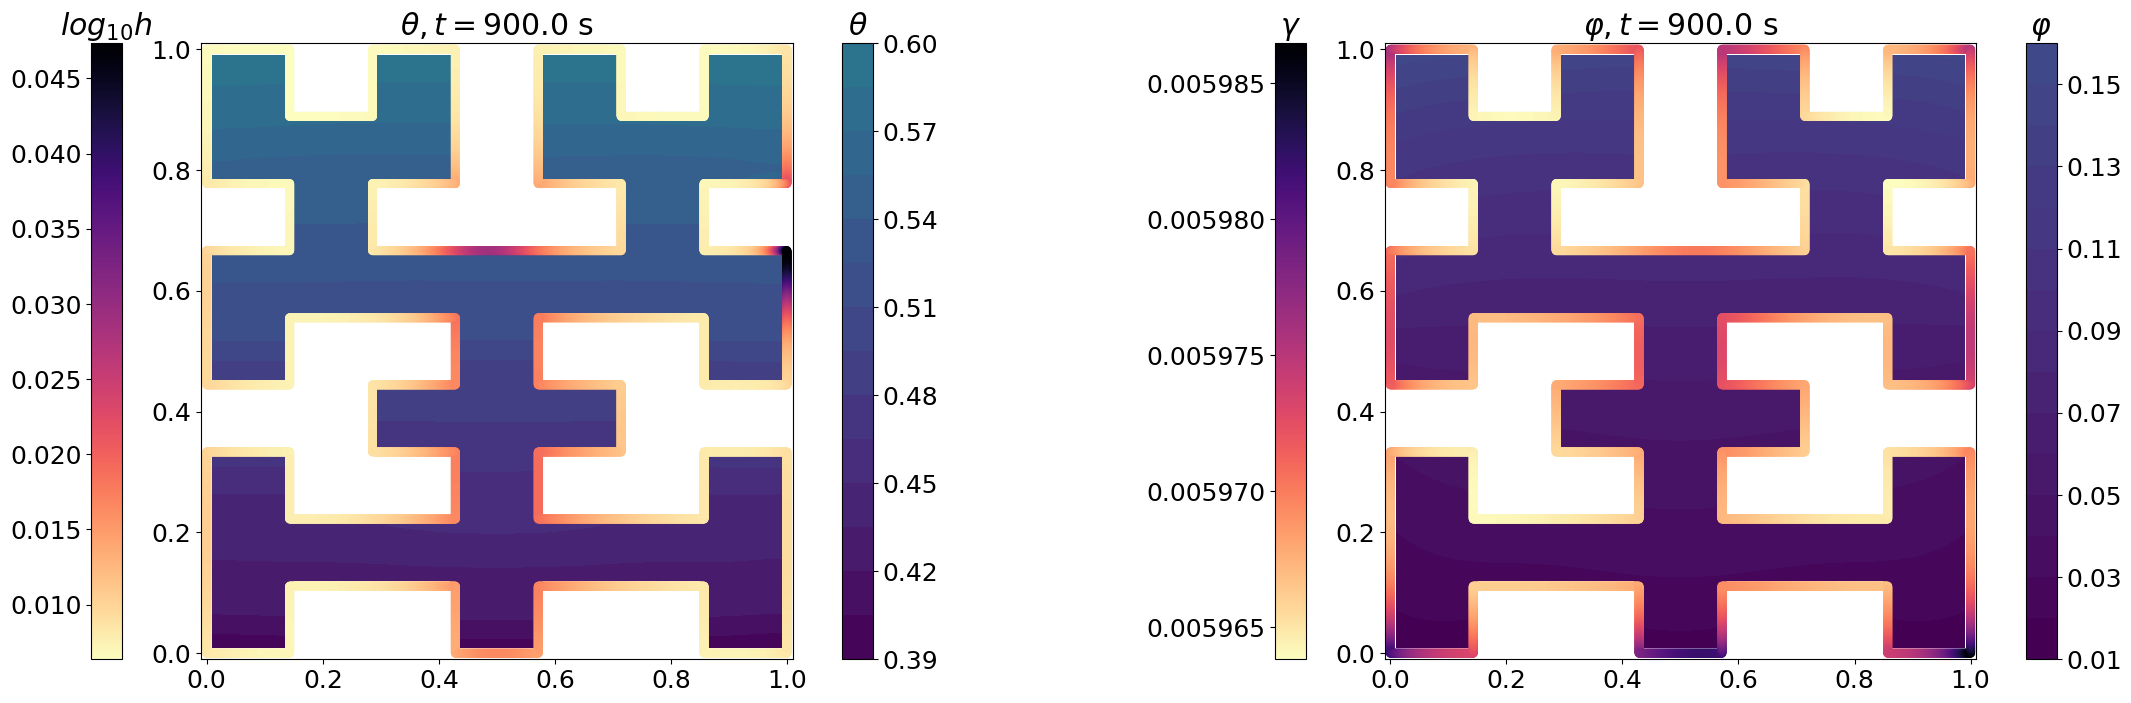

It: 2100 Time: 10.189128875732422 loss_w: 0.000307115202 loss: 5.75489612e-05 J 1.8102679e-05
It: 2200 Time: 8.899980545043945 loss_w: 0.000302932516 loss: 5.65164592e-05 J 1.72962827e-05
It: 2300 Time: 8.453340530395508 loss_w: 0.000298706931 loss: 5.58492866e-05 J 1.65533038e-05
It: 2400 Time: 8.795944690704346 loss_w: 0.000295909063 loss: 5.51633821e-05 J 1.61710504e-05
It: 2500 Time: 8.83484697341919 loss_w: 0.000292107521 loss: 5.37399319e-05 J 1.53698147e-05
It: 2600 Time: 8.988547086715698 loss_w: 0.000289526855 loss: 5.28104829e-05 J 1.49593989e-05
It: 2700 Time: 9.002304792404175 loss_w: 0.000287241419 loss: 5.19000096e-05 J 1.48181171e-05
It: 2800 Time: 8.898204326629639 loss_w: 0.000285211863 loss: 5.10874634e-05 J 1.44973719e-05
It: 2900 Time: 8.746834993362427 loss_w: 0.000282311667 loss: 5.02507864e-05 J 1.39972735e-05
It: 3000 Time: 8.746986865997314 loss_w: 0.000280643202 loss: 5.01685754e-05 J 1.40099573e-05


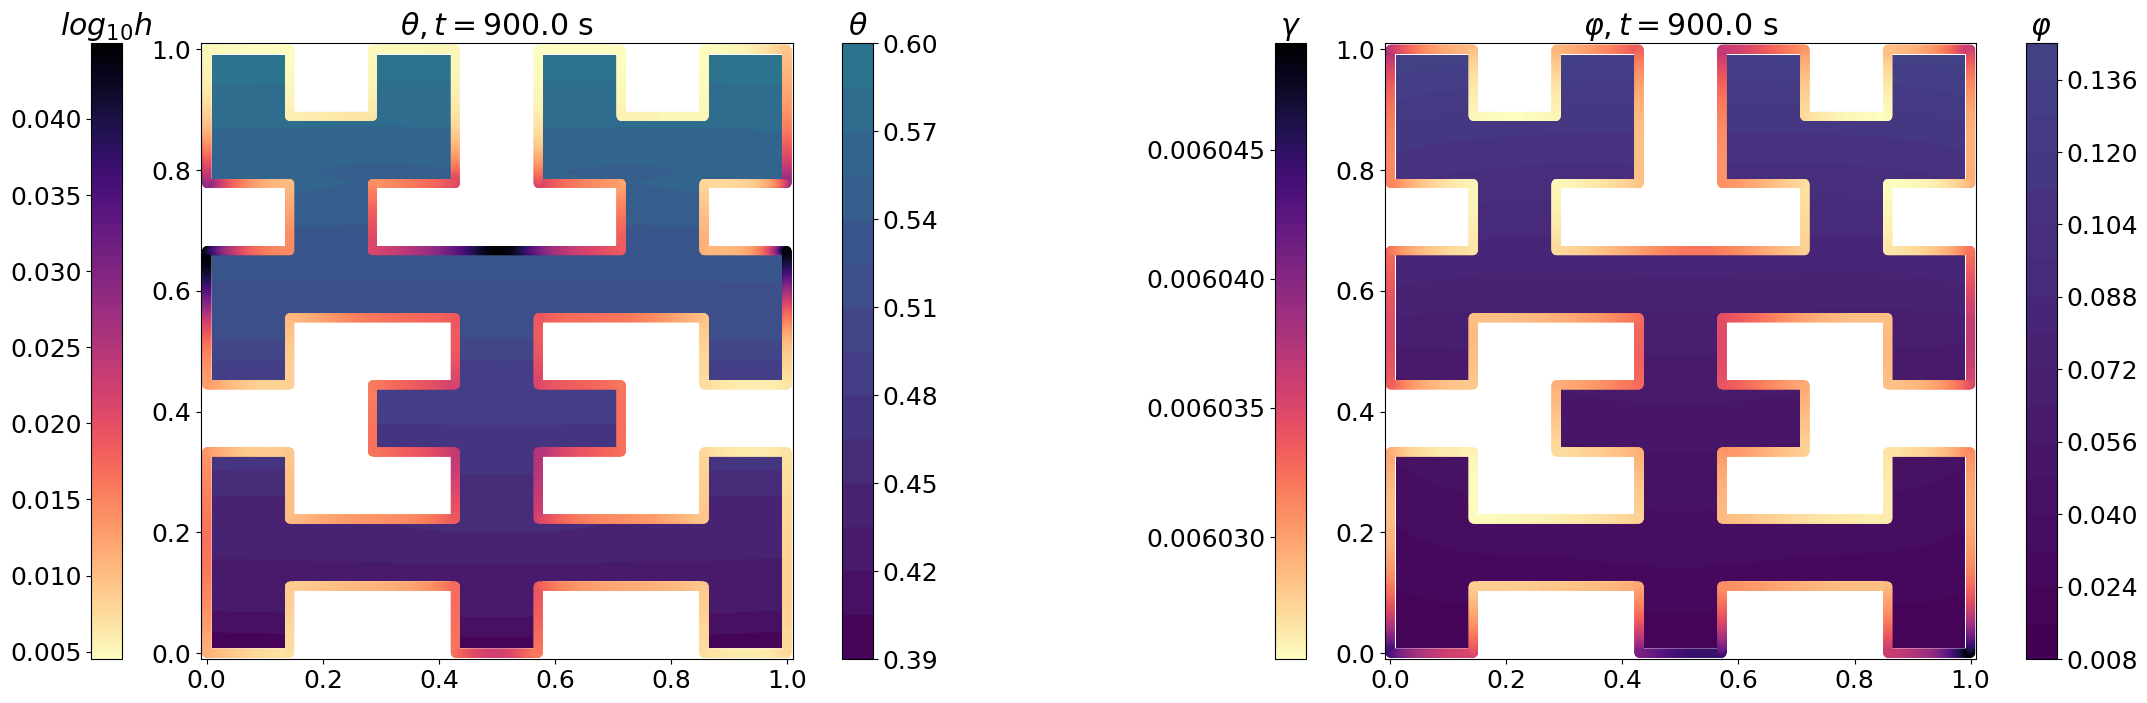

It: 3100 Time: 10.032840490341187 loss_w: 0.000278519641 loss: 4.93542902e-05 J 1.3789765e-05
It: 3200 Time: 8.60042428970337 loss_w: 0.000275792641 loss: 4.81118295e-05 J 1.35003911e-05
It: 3300 Time: 8.409821271896362 loss_w: 0.000275108148 loss: 4.80376402e-05 J 1.35572864e-05
It: 3400 Time: 8.606330394744873 loss_w: 0.000272722944 loss: 4.69835286e-05 J 1.34316278e-05
It: 3500 Time: 8.526695013046265 loss_w: 0.000270836928 loss: 4.60433585e-05 J 1.32464565e-05
It: 3600 Time: 8.514711141586304 loss_w: 0.000269276788 loss: 4.53656503e-05 J 1.31861234e-05
It: 3700 Time: 8.542426347732544 loss_w: 0.000269109121 loss: 4.54863875e-05 J 1.31028173e-05
It: 3800 Time: 8.513470888137817 loss_w: 0.000267058669 loss: 4.39949763e-05 J 1.30870612e-05
It: 3900 Time: 8.525560140609741 loss_w: 0.000266063755 loss: 4.37029121e-05 J 1.30185672e-05
It: 4000 Time: 8.56490159034729 loss_w: 0.000265947427 loss: 4.29866268e-05 J 1.30332865e-05


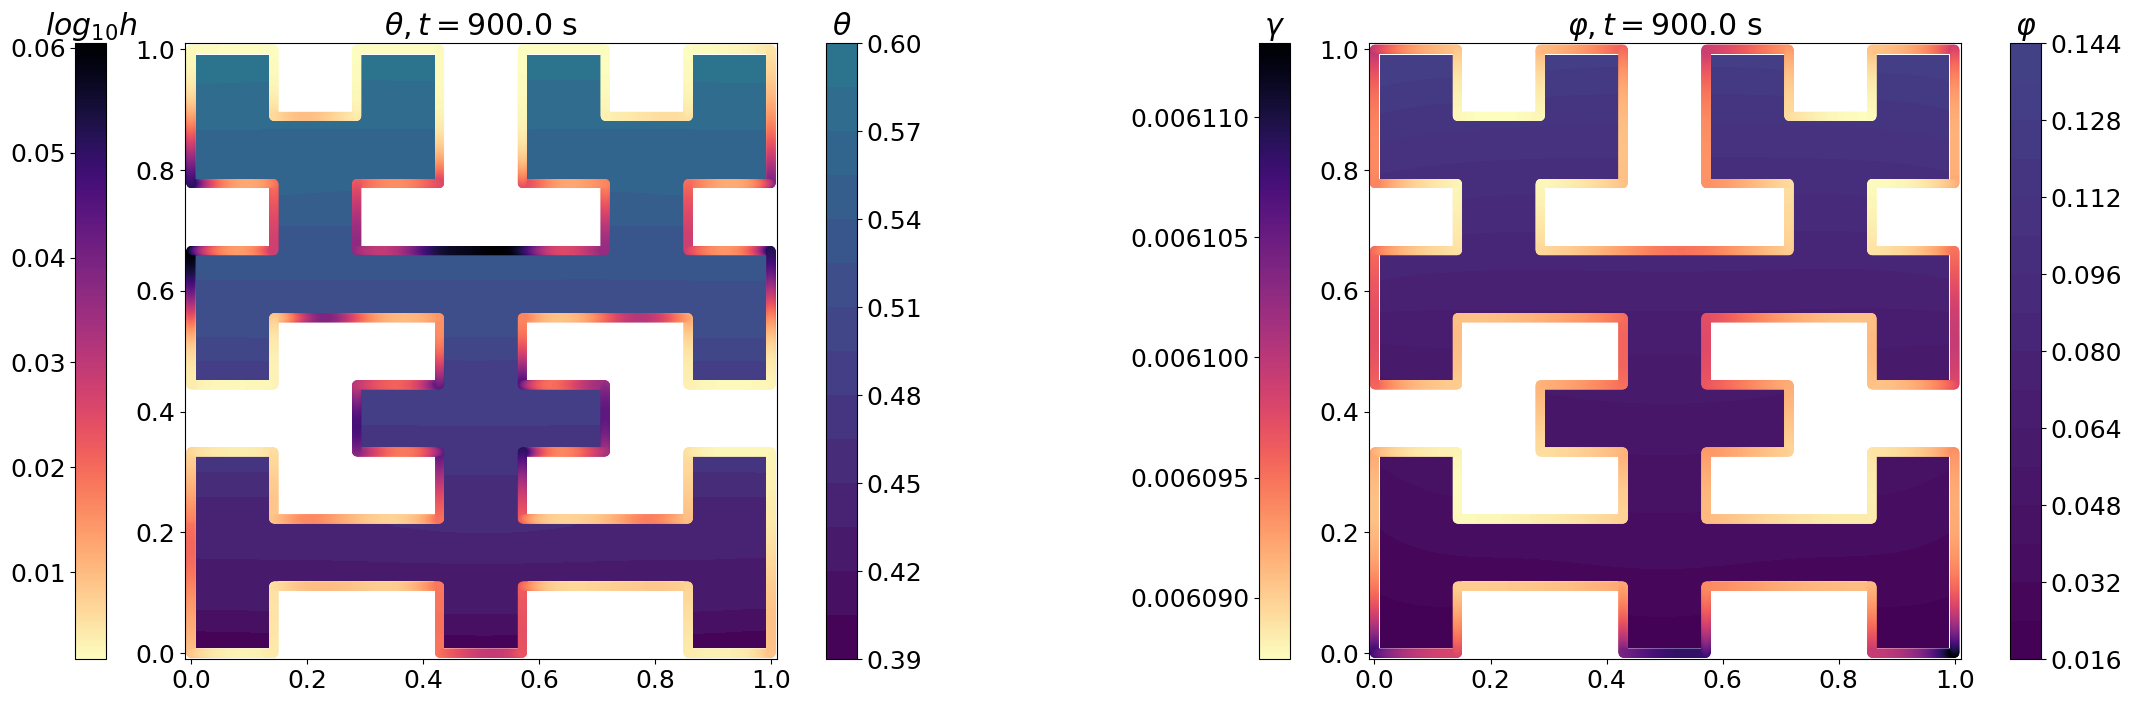

It: 4100 Time: 10.365761280059814 loss_w: 0.000265246432 loss: 4.25304424e-05 J 1.29994523e-05
It: 4200 Time: 9.137242317199707 loss_w: 0.000264873204 loss: 4.20852884e-05 J 1.30795243e-05
It: 4300 Time: 8.873474836349487 loss_w: 0.000264040194 loss: 4.21991499e-05 J 1.28555257e-05
It: 4400 Time: 8.784700393676758 loss_w: 0.000263982598 loss: 4.12739864e-05 J 1.29596192e-05
It: 4500 Time: 8.848687171936035 loss_w: 0.000262939371 loss: 4.10567e-05 J 1.30014569e-05
It: 4600 Time: 8.660631656646729 loss_w: 0.000263416703 loss: 4.05021528e-05 J 1.29132923e-05
It: 4700 Time: 8.810439109802246 loss_w: 0.000262570858 loss: 4.00739882e-05 J 1.29729297e-05
It: 4800 Time: 8.903041124343872 loss_w: 0.000263234 loss: 4.04945531e-05 J 1.30048447e-05
It: 4900 Time: 8.633241176605225 loss_w: 0.000262229936 loss: 3.95622228e-05 J 1.30889639e-05
It: 5000 Time: 8.617380619049072 loss_w: 0.000262262241 loss: 3.89982815e-05 J 1.31045581e-05


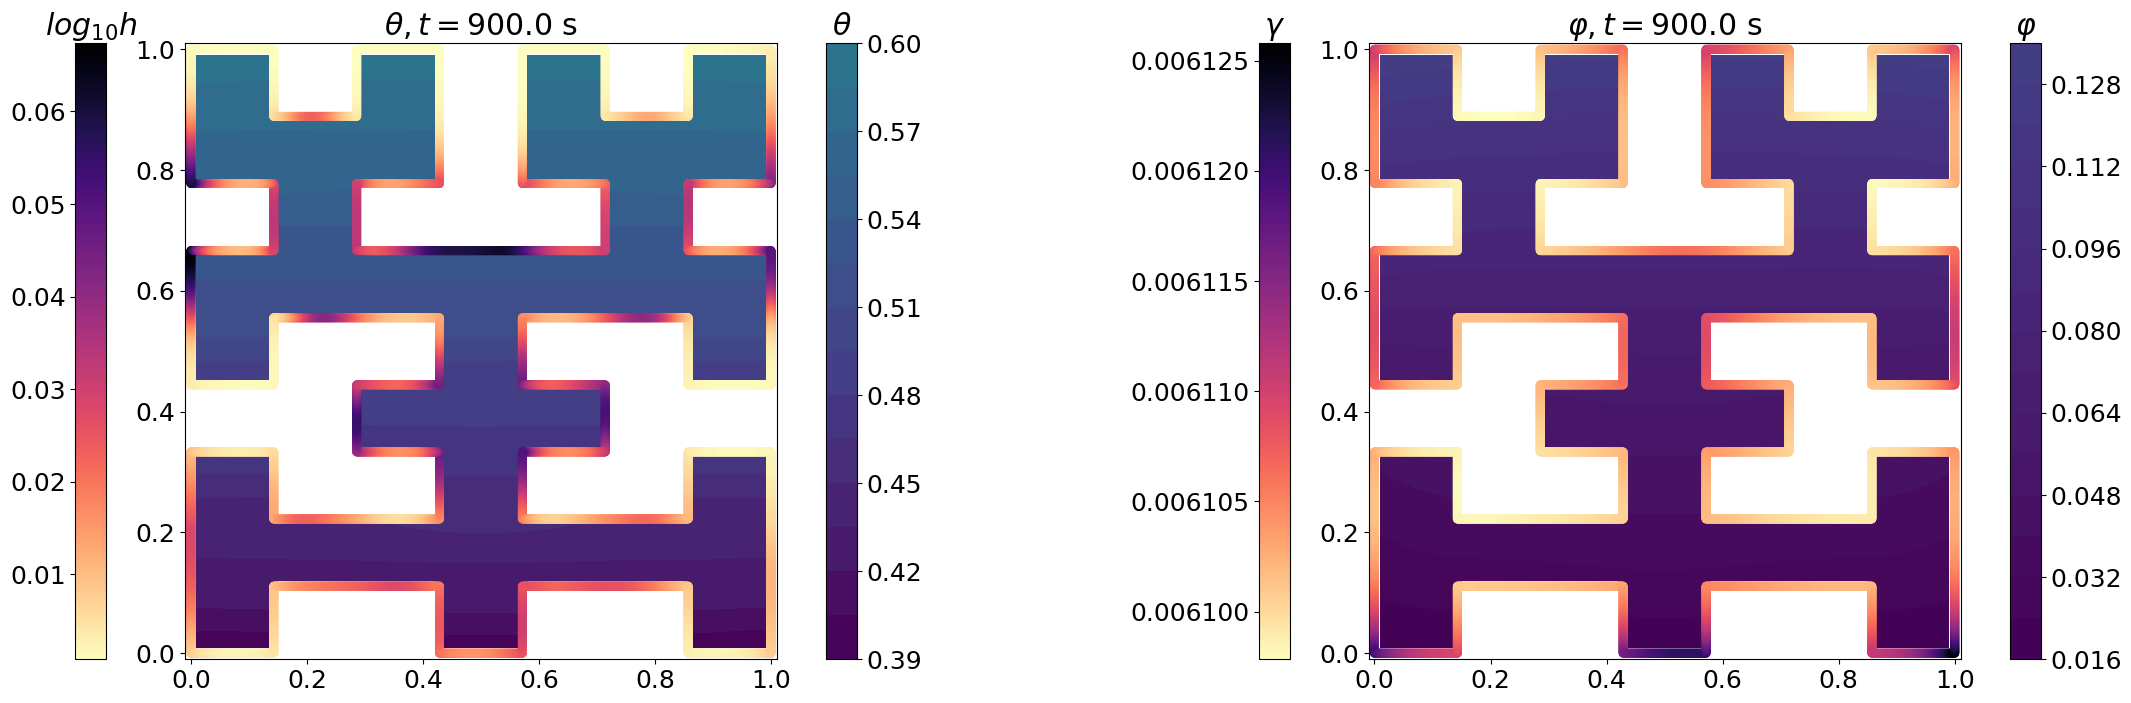

It: 5100 Time: 9.971786260604858 loss_w: 0.000262255286 loss: 3.86676547e-05 J 1.3093636e-05
It: 5200 Time: 8.670516729354858 loss_w: 0.000262221671 loss: 3.85621388e-05 J 1.32463756e-05
It: 5300 Time: 8.910070657730103 loss_w: 0.00026247045 loss: 3.83494698e-05 J 1.32459827e-05
It: 5400 Time: 8.867656946182251 loss_w: 0.00026266955 loss: 3.79988523e-05 J 1.34026213e-05
It: 5500 Time: 8.927926301956177 loss_w: 0.000263943046 loss: 3.8302227e-05 J 1.34145357e-05
It: 5600 Time: 8.645225763320923 loss_w: 0.000263698545 loss: 3.76694807e-05 J 1.36461413e-05
It: 5700 Time: 8.570236682891846 loss_w: 0.00026386659 loss: 3.70052512e-05 J 1.36255885e-05
It: 5800 Time: 8.991329669952393 loss_w: 0.000265132781 loss: 3.68396577e-05 J 1.37081724e-05
It: 5900 Time: 9.332324266433716 loss_w: 0.000264335133 loss: 3.66255263e-05 J 1.36667531e-05
It: 6000 Time: 8.981035470962524 loss_w: 0.000265592564 loss: 3.63331128e-05 J 1.3917228e-05


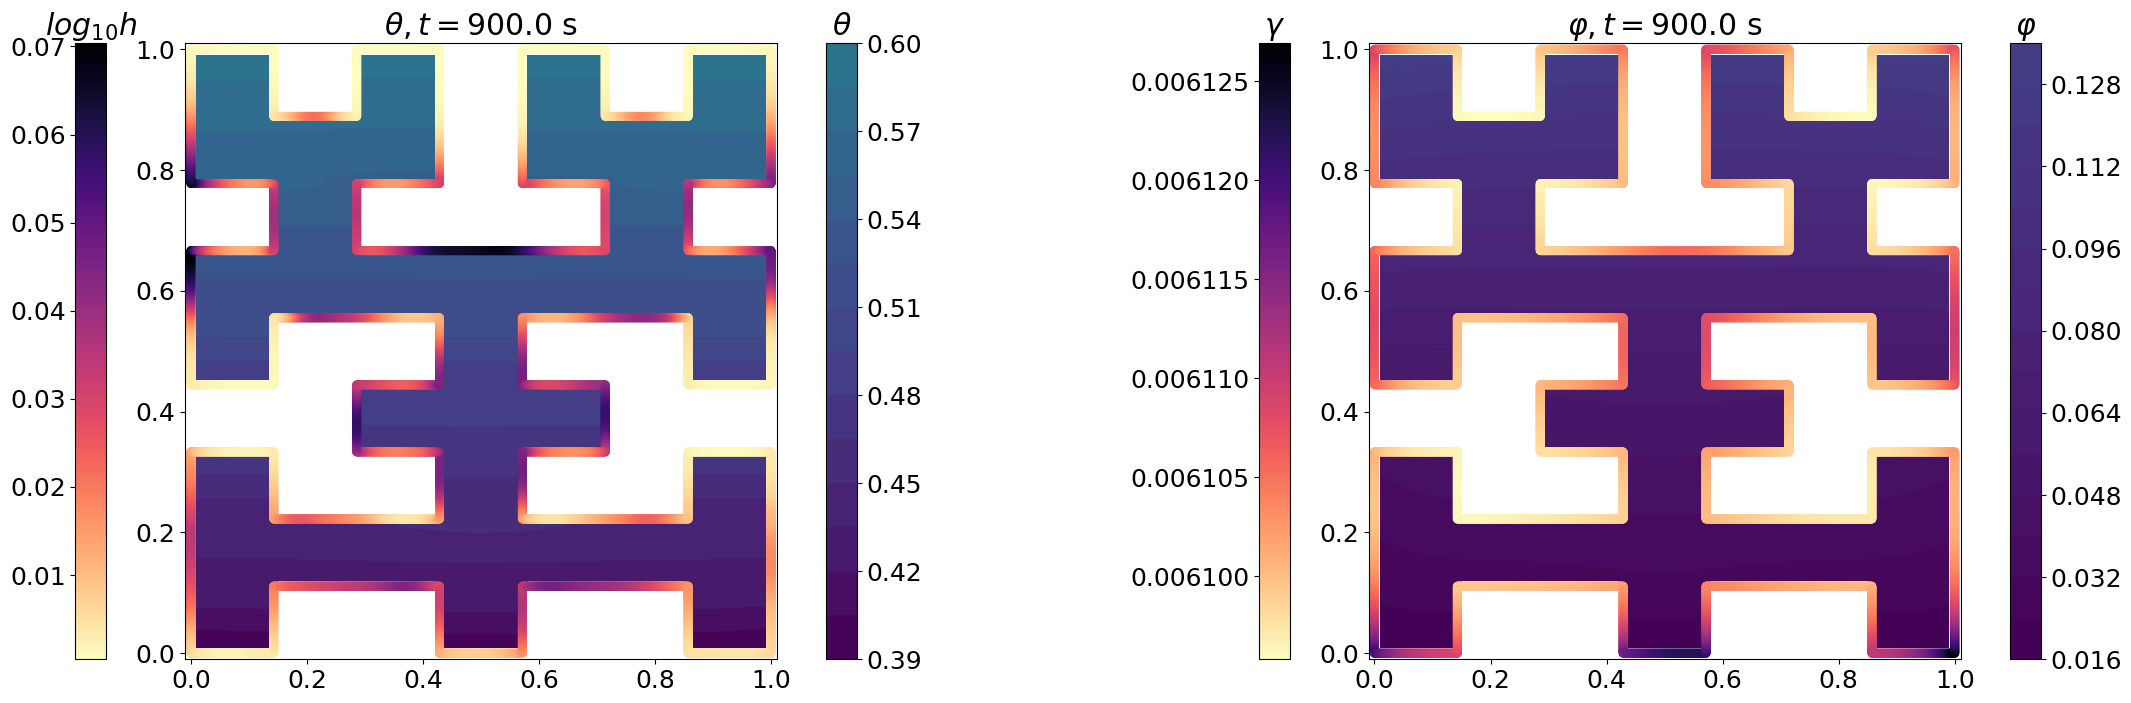

It: 6100 Time: 10.297896146774292 loss_w: 0.000266446586 loss: 3.67738394e-05 J 1.40366446e-05
It: 6200 Time: 9.04422402381897 loss_w: 0.000266499846 loss: 3.64932748e-05 J 1.38879641e-05
It: 6300 Time: 8.68262267112732 loss_w: 0.000266739866 loss: 3.57062163e-05 J 1.41098235e-05
It: 6400 Time: 8.658915519714355 loss_w: 0.00026822614 loss: 3.55946177e-05 J 1.42366089e-05
It: 6500 Time: 8.596964597702026 loss_w: 0.000268445845 loss: 3.53770483e-05 J 1.43520365e-05
It: 6600 Time: 8.71419072151184 loss_w: 0.000268789823 loss: 3.51740237e-05 J 1.4295003e-05
It: 6700 Time: 8.498244524002075 loss_w: 0.000270443241 loss: 3.50850751e-05 J 1.44548349e-05
It: 6800 Time: 8.699231147766113 loss_w: 0.00027031239 loss: 3.47927853e-05 J 1.47068158e-05
It: 6900 Time: 8.843195676803589 loss_w: 0.000270700461 loss: 3.46535489e-05 J 1.4724731e-05
It: 7000 Time: 9.004306554794312 loss_w: 0.00027253828 loss: 3.53198884e-05 J 1.48493837e-05


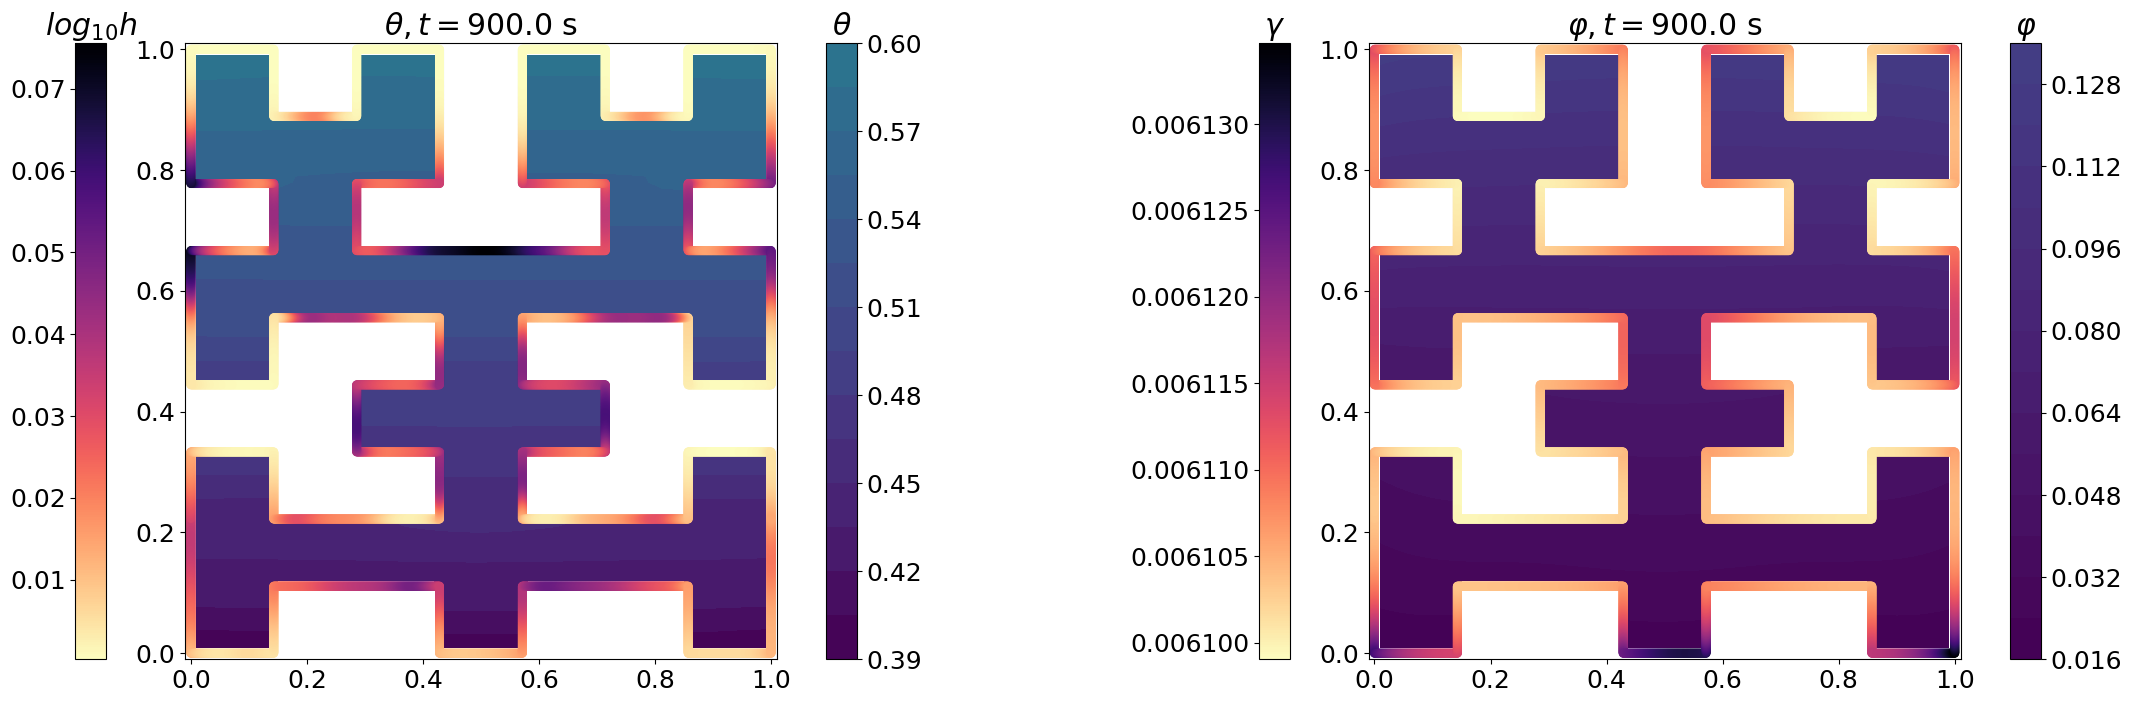

It: 7100 Time: 10.53741192817688 loss_w: 0.000272761332 loss: 3.48903231e-05 J 1.49260513e-05
It: 7200 Time: 8.91155195236206 loss_w: 0.0002730946 loss: 3.43844658e-05 J 1.5223929e-05


KeyboardInterrupt: 

In [16]:
train.fit(17000)

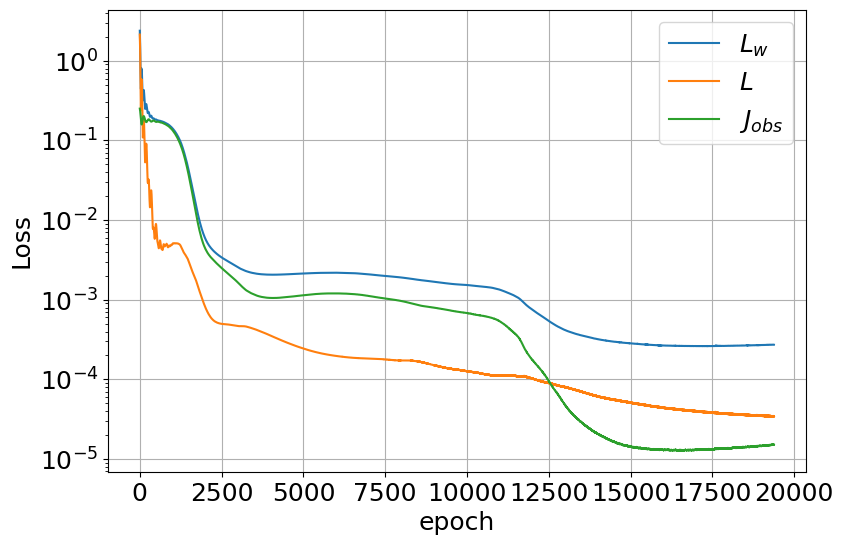

In [20]:
vis.plothist(train.hist1,train.hist2,train.hist3)

In [ ]:
PINN.models[0](gen.X_data[3])-gen.u_data[1]

In [15]:
tf.reduce_max(PINN.models[0](gen.X_data[1]))

<tf.Tensor: shape=(), dtype=float32, numpy=0.8926057>

In [ ]:
gen.u_data[1]

In [ ]:
vis.plotu(0.3)

In [ ]:
gen.X_data[3]

In [ ]:
gen.u_data[1]

In [ ]:
plt.scatter(gen.X_data[1][:,0:1],gen.X_data[1][:,1:2],c=gen.n_data[:,0:1])

In [ ]:
gen.X_data[1]

In [17]:
path=r'C:\Users\Voland\Desktop\art\oop2\models/'

In [18]:
PINN.save(path)

INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art\oop2\models//modeltheta\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art\oop2\models//modeltheta\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art\oop2\models//modelphi\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art\oop2\models//modelphi\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art\oop2\models//modelh\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art\oop2\models//modelh\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art\oop2\models//modelgamma\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art\oop2\models//modelgamma\assets


Models saved to: C:\Users\Voland\Desktop\art\oop2\models/


In [40]:
path = r"C:\Users\Voland\Desktop\art/oop2/func/"
vis.save_all(N=100,path=path)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [41]:
vis.make_gif(
    folder_path=path,
    output_path=r"C:\Users\Voland\Desktop\art/oop2/gif/",
    frame_duration=50,   # smoother = smaller value
    pause_frames=50
)

✅ GIF saved as: C:\Users\Voland\Desktop\art/oop2/gif/


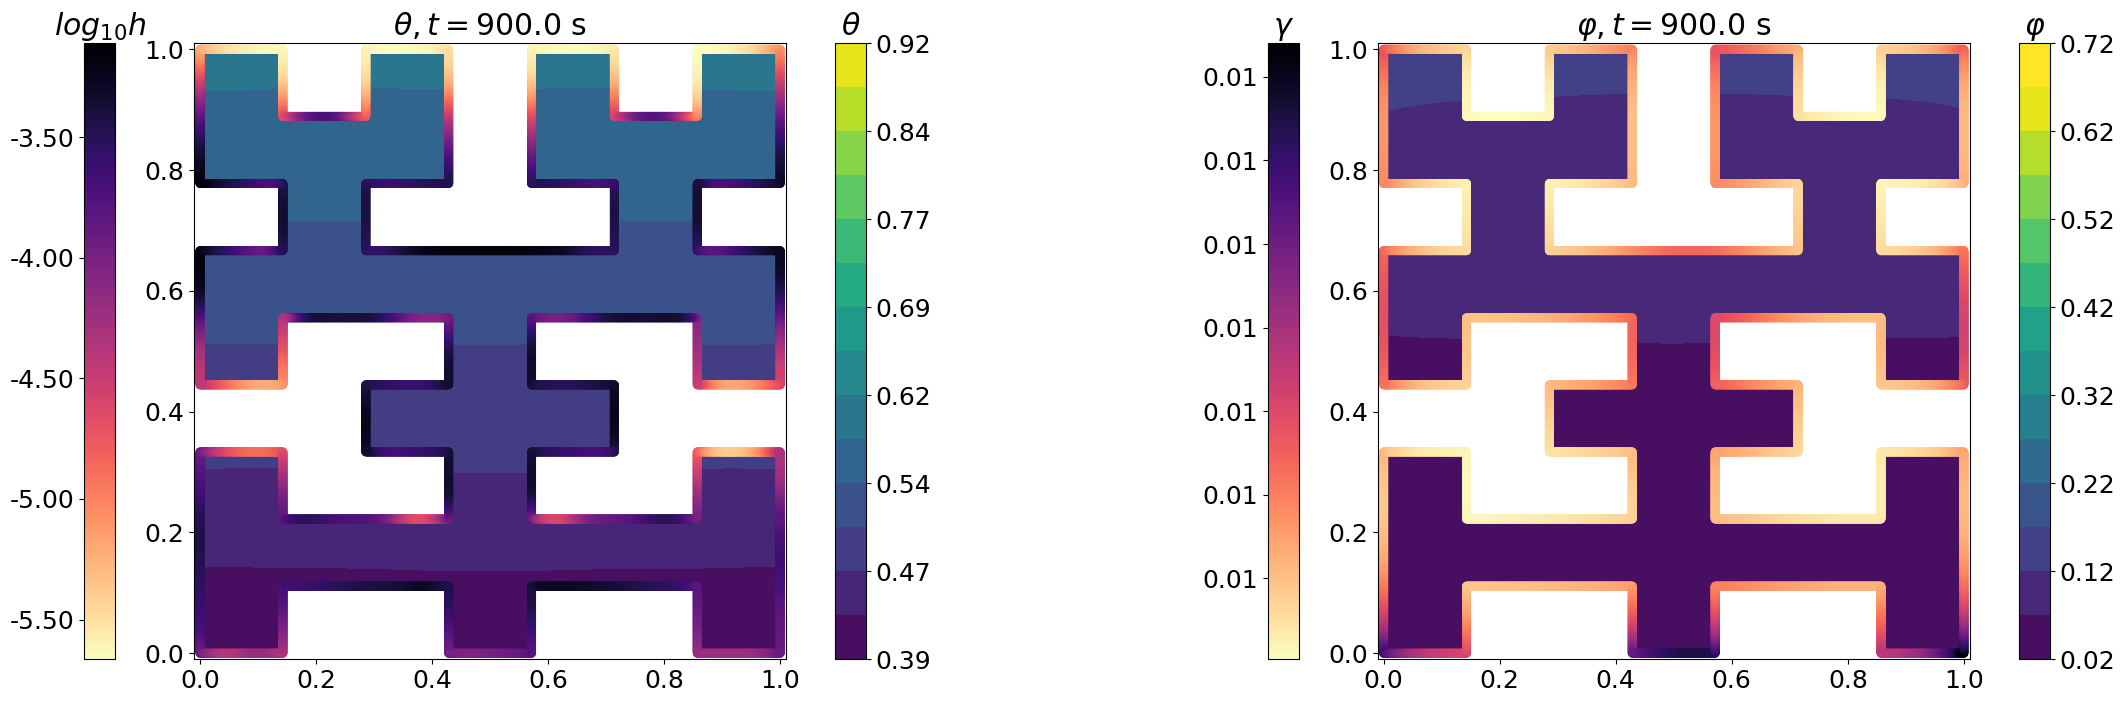

In [39]:
vis = Visualization(cfg,gen, PINN)
vis.plotu(1.)

In [33]:
PINN.models[2](gen.X_data[1][:,0:2])

<tf.Tensor: shape=(11623, 1), dtype=float32, numpy=
array([[0.03274357],
       [0.03285786],
       [0.03297019],
       ...,
       [0.01466616],
       [0.01481786],
       [0.01496956]], dtype=float32)>